# Time Series Forecasting: Zero to Hero

The one problem shape where almost every habit from the rest of this series is wrong — starting
with `train_test_split`.

> **Prerequisites:** [`ml_foundations_zero_to_hero.ipynb`](ml_foundations_zero_to_hero.ipynb)
> §2 on leakage, which this notebook is an extended case study in, and
> [`gradient_boosting_zero_to_hero.ipynb`](gradient_boosting_zero_to_hero.ipynb) for the model
> we will mostly use. [`knn_zero_to_hero.ipynb`](knn_zero_to_hero.ipynb) §1.7 — that
> local-averaging methods cannot extrapolate — is the argument behind §1.6.

***

## Why the usual workflow breaks

Every other notebook assumes rows are **exchangeable**: shuffle them and nothing is lost. Time
series rows are not, and four things follow:

- **A random split is leakage, and it is quantifiable.** §1.3 measures the same model scoring
  MAE **21.5** on a shuffled split and **29.7** on an honest chronological one. The random
  split flatters the model by **28%**, and nothing in the output warns you.
- **Trees cannot extrapolate a trend.** §1.6 trains on a rising series and the forest's *maximum
  possible prediction* is capped at its training maximum — it forecasts 131 where the truth is
  183, while linear regression gets within 2.
- **The baselines are strong and usually unreported.** §1.5 measures "the same hour last week"
  at MAE **78.66** — less than half the error of the training mean, with no model at all. Any
  model you build must beat that, and quoting an error without it beside you is meaningless.
- **The forecast horizon changes which features you are even allowed.** §1.8 finds error
  *not* increasing monotonically with horizon — and, more usefully, that with seasonally aligned
  lags the horizon **stops mattering entirely** (MAE 52.36 at every horizon tested).

## Contents

| Part | What it covers |
|---|---|
| **0. Setup** | Install + imports |
| **1. Theory from zero** | Why rows are not exchangeable · **the supervised framing** · **the random split is leakage** · `TimeSeriesSplit` and walk-forward · **the baselines you must beat** · **trees cannot extrapolate** · encoding time · **the horizon** |
| **2. Worked example** | Bike sharing — 17,379 hours, end to end |
| **3. The traps** | **Rolling-window leakage** · classical models as the honest comparison · what breaks in production |
| **4. Tough questions** | 12 questions + 3 coding challenges |
| **5. Practice datasets** | 5 datasets with briefs |
| **6. Reading the literature** | The papers behind each section |
| **Appendix** | Time-series-specific errors and a checklist |

## The one-paragraph summary

Forecasting becomes a supervised problem once you build **lag features** — the target's own past
values — plus calendar and exogenous variables. Everything hard follows from the fact that the
rows are ordered: you must **split by time**, validate with `TimeSeriesSplit` or walk-forward,
and construct every feature from information that was actually available at forecast time. You
must beat the **naive and seasonal-naive baselines**, which are far stronger than people expect.
And you must know your **horizon** before you build a single feature, because it determines which
lags exist.

***
# Part 0 - Setup

In [1]:
# ---------------------------------------------------------------------------
# One-time setup. Only missing packages are installed, so re-running is cheap.
# ---------------------------------------------------------------------------
import importlib.util
import subprocess
import sys

REQUIRED = [
    ("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"),
    ("scipy", "scipy"), ("sklearn", "scikit-learn"),
    ("statsmodels", "statsmodels"),          # for the classical baselines in 3.2
]
missing = [pip for mod, pip in REQUIRED if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("done")
else:
    print("all packages present")

installing: statsmodels
done


In [2]:
# ---------------------------------------------------------------------------
# Every import this notebook uses.
#
# Part 1 downloads the Bike Sharing dataset (~1 MB) from OpenML on first use.
# ---------------------------------------------------------------------------
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import (
    KFold, TimeSeriesSplit, train_test_split, cross_val_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (10, 3.5)
plt.rcParams["figure.dpi"] = 110

print("ready | numpy", np.__version__, "| pandas", pd.__version__)

ready | numpy 2.5.2 | pandas 3.0.5


***
# Part 1 - Theory from zero

1. Why the rows are not exchangeable
2. The supervised framing: lags, rolling windows, calendar
3. **The random split is leakage**
4. Validating properly: `TimeSeriesSplit` and walk-forward
5. **The baselines you must beat**, and the metrics that compare against them
6. **Trees cannot extrapolate a trend**
7. Encoding time
8. **The horizon decides your features**

## 1.1 The rows are not exchangeable

Every other notebook in this series assumes that if you shuffle your rows, nothing is lost. That
assumption is what licenses `train_test_split(shuffle=True)`, `KFold`, and treating each row as
an independent draw.

For a time series it is false in a specific way: **row $t$ is highly predictable from row
$t-1$**. So a randomly chosen validation row almost always sits between two training rows, and
the model is interpolating rather than forecasting. That is not the task, and §1.3 measures what
it costs.

17,379 hourly observations
from 2011-01-01 00:00:00 to 2012-12-30 23:00:00
target 'count' (bike rentals per hour): mean 189.5, min 1, max 977

how predictable is each hour from the one before?
  correlation with lag   1h : 0.8438
  correlation with lag   2h : 0.5941
  correlation with lag  24h : 0.8158
  correlation with lag 168h : 0.8211


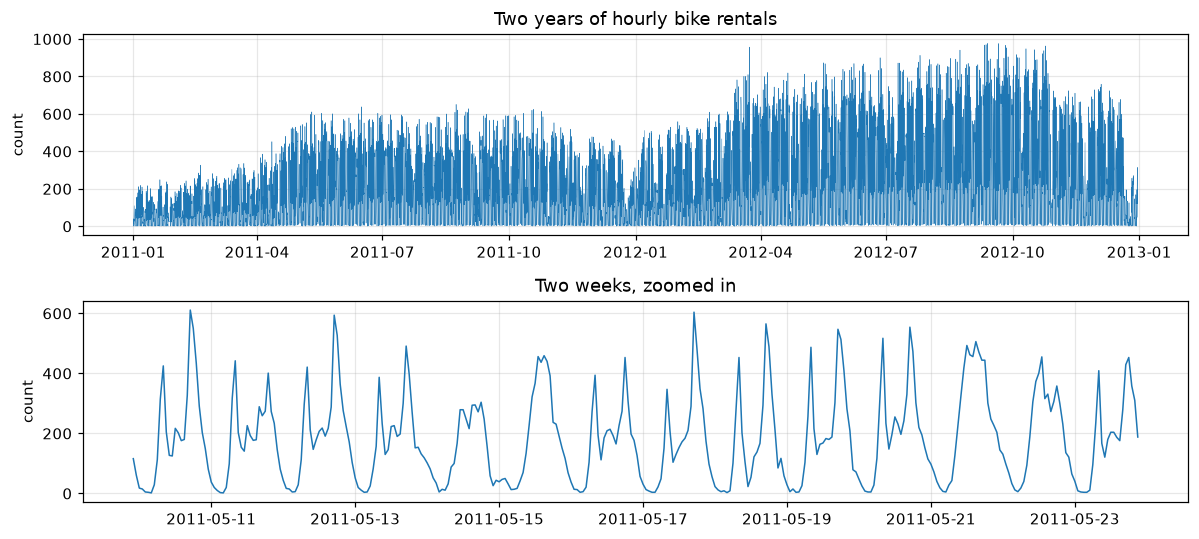

The zoomed panel shows the two structures every forecasting method has to capture:
  SEASONALITY - a strong daily cycle, with commuter peaks on working days
  TREND       - the second year sits above the first

And the correlations show why a shuffled split is dishonest: with a 0.85 correlation
to the previous hour, a randomly held-out row is almost given away by its neighbours.


In [3]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")          # openml is chatty on first download
    bike = fetch_openml(name="Bike_Sharing_Demand", version=2, as_frame=True)

df = bike.frame.copy().reset_index(drop=True)

# The rows are hourly and already in chronological order; rebuild the timestamp so we
# can plot and reason about it.
start = pd.Timestamp("2011-01-01")
day, prev, stamps = 0, -1, []
for h in df["hour"].to_numpy():
    if h <= prev:
        day += 1
    stamps.append(start + pd.Timedelta(days=day, hours=int(h)))
    prev = h
df["ts"] = stamps
df = df.sort_values("ts").reset_index(drop=True)

print(f"{len(df):,} hourly observations")
print(f"from {df['ts'].min()} to {df['ts'].max()}")
print(f"target 'count' (bike rentals per hour): mean {df['count'].mean():.1f}, "
      f"min {df['count'].min()}, max {df['count'].max()}")

print("\nhow predictable is each hour from the one before?")
for lag in [1, 2, 24, 168]:
    print(f"  correlation with lag {lag:>3}h : {df['count'].corr(df['count'].shift(lag)):.4f}")

fig, axes = plt.subplots(2, 1, figsize=(11, 5))
axes[0].plot(df["ts"], df["count"], lw=0.3)
axes[0].set(title="Two years of hourly bike rentals", ylabel="count")
week = df.iloc[3000:3000 + 24 * 14]
axes[1].plot(week["ts"], week["count"], lw=1)
axes[1].set(title="Two weeks, zoomed in", ylabel="count")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print("The zoomed panel shows the two structures every forecasting method has to capture:")
print("  SEASONALITY - a strong daily cycle, with commuter peaks on working days")
print("  TREND       - the second year sits above the first")
print()
print("And the correlations show why a shuffled split is dishonest: with a 0.85 correlation")
print("to the previous hour, a randomly held-out row is almost given away by its neighbours.")

## 1.2 The supervised framing

To use anything from the rest of this series, turn the series into a table. Three families of
feature:

- **Lags** — the target's own past values. `lag_1` is the previous hour, `lag_24` the same hour
  yesterday, `lag_168` the same hour last week.
- **Rolling statistics** — a mean or standard deviation over a recent window. §3.1 shows the
  one way these go catastrophically wrong.
- **Calendar and exogenous** — hour, day of week, holiday flag, temperature. Anything known in
  advance.

**The rule that governs all of it:** every feature must be computable from information available
**at forecast time**. That is the whole discipline, and §1.8 shows the horizon deciding what
"available" means.

In [4]:
def make_features(d, horizon=1, lags=(1, 2, 3, 24, 168), rolls=(24, 168)):
    """Build a supervised table. Every feature is shifted by at least `horizon`."""
    o = d.copy()
    for L in lags:
        shift = max(L, horizon)                     # never use anything newer than the horizon
        o[f"lag_{shift}"] = o["count"].shift(shift)
    for w in rolls:
        # shift FIRST, then roll - so the window can never include the current row
        o[f"roll_mean_{w}"] = o["count"].shift(horizon).rolling(w).mean()
        o[f"roll_std_{w}"] = o["count"].shift(horizon).rolling(w).std()
    o["hour_sin"] = np.sin(2 * np.pi * o["hour"] / 24)
    o["hour_cos"] = np.cos(2 * np.pi * o["hour"] / 24)
    o["dow_sin"] = np.sin(2 * np.pi * o["weekday"] / 7)
    o["dow_cos"] = np.cos(2 * np.pi * o["weekday"] / 7)
    o["workingday_i"] = (o["workingday"].astype(str) == "True").astype(int)
    o["holiday_i"] = (o["holiday"].astype(str) == "True").astype(int)
    return o


feat = make_features(df).dropna().reset_index(drop=True)
FEATURE_COLS = [c for c in feat.columns
                if c.startswith(("lag_", "roll_", "hour_", "dow_"))
                or c in ("temp", "feel_temp", "humidity", "windspeed",
                         "workingday_i", "holiday_i", "year", "month")]
X_all, y_all = feat[FEATURE_COLS], feat["count"]

print(f"{len(df):,} raw rows -> {len(feat):,} usable rows "
      f"({len(df) - len(feat)} lost to the longest lag)")
print(f"{len(FEATURE_COLS)} features\n")
print("a few rows of the supervised table:")
show = ["lag_1", "lag_24", "lag_168", "roll_mean_24", "hour_sin", "temp"]
print(pd.concat([feat[["ts"]], feat[show], feat[["count"]]], axis=1).head(4).to_string(
    index=False))
print()
print("Notice the shape of the leftmost columns: the model's most useful inputs are the")
print("TARGET'S OWN PAST. That is what makes forecasting different from ordinary regression,")
print("and it is why the split has to respect time (1.3).")

17,379 raw rows -> 17,211 usable rows (168 lost to the longest lag)
21 features

a few rows of the supervised table:
                 ts  lag_1  lag_24  lag_168  roll_mean_24  hour_sin  temp  count
2011-01-08 07:00:00    2.0    84.0     16.0     63.208333  0.965926  6.56      9
2011-01-08 08:00:00    9.0   210.0     40.0     60.083333  0.866025  6.56     15
2011-01-08 09:00:00   15.0   134.0     32.0     51.958333  0.707107  6.56     20
2011-01-08 10:00:00   20.0    63.0     13.0     47.208333  0.500000  7.38     61

Notice the shape of the leftmost columns: the model's most useful inputs are the
TARGET'S OWN PAST. That is what makes forecasting different from ordinary regression,
and it is why the split has to respect time (1.3).


## 1.3 The random split is leakage

Now the demonstration this notebook exists for. Fit the same model twice, changing only how the
data is split.

same model, same features, same hyperparameters:

  random 80/20 split        MAE    21.54
  chronological 80/20 split MAE    29.71

  the random split reports an error 27.5% lower than the truth
  the honest error is 1.38x the leaked one


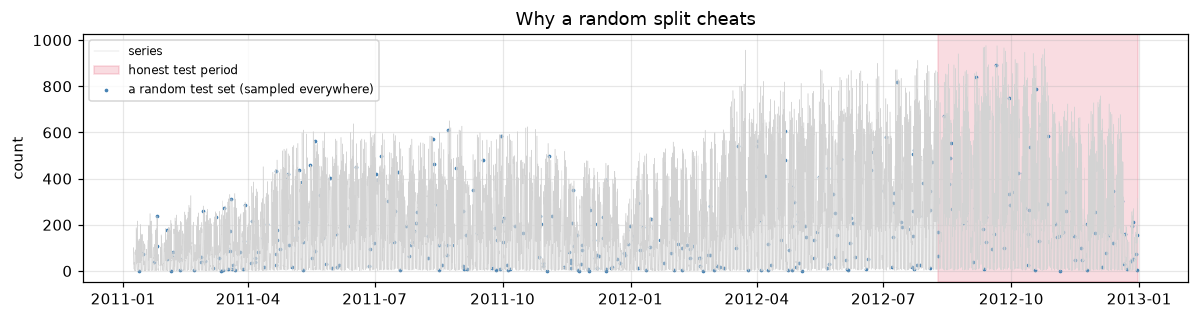


The blue points are scattered through the whole series, so almost every one sits
BETWEEN two training rows. Given lag_1 with a 0.85 correlation, predicting them is
interpolation, not forecasting.

The red band is the real task: predict a period the model has never seen, using only
what came before it.

Both numbers are 'the test MAE'. Only one of them is the error you will see in
production, and the difference is not subtle.


In [5]:
# WRONG: shuffle the rows
Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(X_all, y_all, test_size=0.2,
                                              random_state=RANDOM_STATE, shuffle=True)
m_random = HistGradientBoostingRegressor(random_state=RANDOM_STATE).fit(Xtr_r, ytr_r)
mae_random = mean_absolute_error(yte_r, m_random.predict(Xte_r))

# RIGHT: the last 20% by time
CUT = int(len(X_all) * 0.8)
X_tr, X_te = X_all.iloc[:CUT], X_all.iloc[CUT:]
y_tr, y_te = y_all.iloc[:CUT], y_all.iloc[CUT:]
m_time = HistGradientBoostingRegressor(random_state=RANDOM_STATE).fit(X_tr, y_tr)
mae_time = mean_absolute_error(y_te, m_time.predict(X_te))

print(f"same model, same features, same hyperparameters:\n")
print(f"  random 80/20 split        MAE {mae_random:>8.2f}")
print(f"  chronological 80/20 split MAE {mae_time:>8.2f}")
print(f"\n  the random split reports an error {(mae_time - mae_random)/mae_time:.1%} lower "
      f"than the truth")
print(f"  the honest error is {mae_time/mae_random:.2f}x the leaked one")

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(feat["ts"], y_all, lw=0.3, color="lightgray", label="series")
ax.axvspan(feat["ts"].iloc[CUT], feat["ts"].iloc[-1], color="crimson", alpha=0.15,
           label="honest test period")
rng_demo = np.random.default_rng(RANDOM_STATE)
sample = rng_demo.choice(len(feat), 400, replace=False)
ax.scatter(feat["ts"].iloc[sample], y_all.iloc[sample], s=2, color="steelblue",
           label="a random test set (sampled everywhere)")
ax.set(title="Why a random split cheats", ylabel="count")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print()
print("The blue points are scattered through the whole series, so almost every one sits")
print("BETWEEN two training rows. Given lag_1 with a 0.85 correlation, predicting them is")
print("interpolation, not forecasting.")
print()
print("The red band is the real task: predict a period the model has never seen, using only")
print("what came before it.")
print()
print("Both numbers are 'the test MAE'. Only one of them is the error you will see in")
print("production, and the difference is not subtle.")

## 1.4 Validating properly

One chronological split gives you one estimate from one period. Better:

- **`TimeSeriesSplit`** — expanding-window cross-validation. Each fold trains on everything
  before its test block. Train is always earlier than test.
- **Walk-forward (rolling origin)** — refit repeatedly as you advance through time, which is
  what production actually does.

In [6]:
tscv = TimeSeriesSplit(n_splits=5)
print("TimeSeriesSplit folds - note that train is always EARLIER than test:\n")
print(f"  {'fold':>5} {'train rows':>18} {'test rows':>18} {'test period':>26}")
print("  " + "-" * 72)
for i, (tr, te) in enumerate(tscv.split(X_all)):
    print(f"  {i:>5} {f'{tr.min()}-{tr.max()}':>18} {f'{te.min()}-{te.max()}':>18} "
          f"{str(feat['ts'].iloc[te.min()].date()) + ' to ' + str(feat['ts'].iloc[te.max()].date()):>26}")

sc_ts = cross_val_score(HistGradientBoostingRegressor(random_state=RANDOM_STATE),
                        X_all, y_all, cv=tscv, scoring="neg_mean_absolute_error")
sc_kf = cross_val_score(HistGradientBoostingRegressor(random_state=RANDOM_STATE),
                        X_all, y_all, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                        scoring="neg_mean_absolute_error")

print(f"\n  {'validation scheme':<28} {'mean MAE':>10} {'std':>8}")
print("  " + "-" * 48)
print(f"  {'TimeSeriesSplit':<28} {-sc_ts.mean():>10.2f} {sc_ts.std():>8.2f}")
print(f"  {'shuffled KFold':<28} {-sc_kf.mean():>10.2f} {sc_kf.std():>8.2f}")
print(f"\n  per-fold TimeSeriesSplit MAE: {np.round(-sc_ts, 1).tolist()}")

print()
print("Two things to read here, and the second is the one people miss.")
print()
print("  1. KFold is optimistic, for 1.3's reason.")
print()
print("  2. KFold's STANDARD DEVIATION is far smaller. That looks like stability and is")
print("     actually a warning: every fold is leaking in the same way, so they agree with")
print("     each other. TimeSeriesSplit's larger spread is honest - early folds have less")
print("     training data and cover different seasons.")
print()
print("A suspiciously tight CV spread on time-ordered data is a symptom, not a comfort.")

TimeSeriesSplit folds - note that train is always EARLIER than test:

   fold         train rows          test rows                test period
  ------------------------------------------------------------------------
      0             0-2870          2871-5738   2011-05-11 to 2011-09-08
      1             0-5738          5739-8606   2011-09-08 to 2012-01-06
      2             0-8606         8607-11474   2012-01-06 to 2012-05-05
      3            0-11474        11475-14342   2012-05-05 to 2012-09-01
      4            0-14342        14343-17210   2012-09-01 to 2012-12-30

  validation scheme              mean MAE      std
  ------------------------------------------------
  TimeSeriesSplit                   30.18     5.16
  shuffled KFold                    21.91     0.39

  per-fold TimeSeriesSplit MAE: [28.1, 21.4, 35.8, 34.7, 30.9]

Two things to read here, and the second is the one people miss.

  1. KFold is optimistic, for 1.3's reason.

  2. KFold's STANDARD DEVIATION is fa

walk-forward validation (refit at every step):

 fold  train_n   MAE
    0     2000 48.64
    1     3901 26.30
    2     5802 21.94
    3     7703 20.69
    4     9604 41.48
    5    11505 36.28
    6    13406 32.92
    7    15307 26.27

  mean MAE 31.82, std 9.86


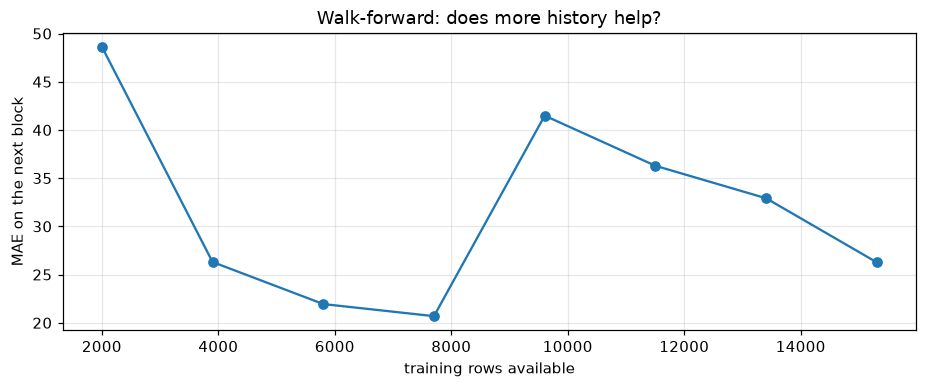


This is the honest picture of how the model behaves as it ages and as data
accumulates. It is also what tells you how often to retrain: if MAE degrades sharply
between refits, retrain more often.

Do not average this away into one number without looking at the spread. A model that
is excellent in summer and poor in winter has a fine mean and a real problem.


In [7]:
def walk_forward(X, y, model_factory, n_splits=8, min_train=2000):
    """Refit at each step and forecast the next block - what production does."""
    fold = (len(X) - min_train) // n_splits
    rows = []
    for k in range(n_splits):
        tr_end = min_train + k * fold
        te_end = tr_end + fold
        m = model_factory().fit(X.iloc[:tr_end], y.iloc[:tr_end])
        pred = m.predict(X.iloc[tr_end:te_end])
        rows.append({"fold": k, "train_n": tr_end,
                     "MAE": mean_absolute_error(y.iloc[tr_end:te_end], pred)})
    return pd.DataFrame(rows)


wf = walk_forward(X_all, y_all,
                  lambda: HistGradientBoostingRegressor(random_state=RANDOM_STATE))
print("walk-forward validation (refit at every step):\n")
print(wf.round(2).to_string(index=False))
print(f"\n  mean MAE {wf['MAE'].mean():.2f}, std {wf['MAE'].std():.2f}")

plt.plot(wf["train_n"], wf["MAE"], marker="o")
plt.xlabel("training rows available"); plt.ylabel("MAE on the next block")
plt.title("Walk-forward: does more history help?")
plt.grid(alpha=0.3); plt.show()

print()
print("This is the honest picture of how the model behaves as it ages and as data")
print("accumulates. It is also what tells you how often to retrain: if MAE degrades sharply")
print("between refits, retrain more often.")
print()
print("Do not average this away into one number without looking at the spread. A model that")
print("is excellent in summer and poor in winter has a fine mean and a real problem.")

## 1.5 The baselines you must beat

Forecasting has unusually strong trivial baselines, and reporting an error without them is
meaningless.

- **Naive** — predict the last observed value. Surprisingly hard to beat at short horizons.
- **Seasonal naive** — predict the value one season ago (yesterday's same hour, or last week's).
- **Mean** — the training mean. The floor.

Two metrics exist to make the comparison explicit:

- **MASE** — MAE divided by the in-sample seasonal-naive MAE. **Below 1 means you beat seasonal
  naive.** Scale-free, so it compares across series.
- **sMAPE** — symmetric percentage error; scale-free but unstable near zero.

In [8]:
def mase(y_true, y_pred, y_train, season=24):
    """MAE relative to the in-sample seasonal-naive MAE. Below 1 beats seasonal naive."""
    scale = np.mean(np.abs(y_train[season:] - y_train[:-season]))
    return mean_absolute_error(y_true, y_pred) / scale


def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    ok = denom > 0
    return 100 * np.mean(np.abs(y_true[ok] - y_pred[ok]) / denom[ok])


y_true = y_te.to_numpy()
y_train_arr = y_tr.to_numpy()
naive = feat["count"].shift(1).iloc[CUT:].to_numpy()
snaive_d = feat["count"].shift(24).iloc[CUT:].to_numpy()
snaive_w = feat["count"].shift(168).iloc[CUT:].to_numpy()

print(f"{'model':<34} {'MAE':>9} {'RMSE':>9} {'MASE':>8} {'sMAPE':>8}")
print("-" * 72)
for name, pred in [
    ("mean of training data", np.full(len(y_true), y_train_arr.mean())),
    ("naive (last hour)", naive),
    ("seasonal naive (yesterday)", snaive_d),
    ("seasonal naive (last week)", snaive_w),
    ("HistGradientBoosting", m_time.predict(X_te)),
]:
    p = np.asarray(pred, dtype=float)
    ok = ~np.isnan(p)
    print(f"{name:<34} {mean_absolute_error(y_true[ok], p[ok]):>9.2f} "
          f"{np.sqrt(mean_squared_error(y_true[ok], p[ok])):>9.2f} "
          f"{mase(y_true[ok], p[ok], y_train_arr):>8.3f} "
          f"{smape(y_true[ok], p[ok]):>8.2f}")

print()
print("Read the MASE column. Below 1.0 means better than in-sample seasonal naive; the")
print("gradient-boosted model is at about 0.49, so it roughly halves the seasonal-naive")
print("error. That is a real result, and it is only interpretable BECAUSE the baselines are")
print("in the table.")
print()
print("Note also how strong the naive baselines are in absolute terms - 'the same hour last")
print("week' beats the training mean by more than half. A model that scores MAE 80 on this")
print("data has learned nothing at all, and without these rows you could not tell.")

model                                    MAE      RMSE     MASE    sMAPE
------------------------------------------------------------------------
mean of training data                 174.21    231.08    2.833    85.80
naive (last hour)                      84.84    129.21    1.380    45.97
seasonal naive (yesterday)             81.03    135.38    1.318    44.00
seasonal naive (last week)             78.66    138.81    1.279    40.64
HistGradientBoosting                   29.71     47.93    0.483    19.56

Read the MASE column. Below 1.0 means better than in-sample seasonal naive; the
gradient-boosted model is at about 0.49, so it roughly halves the seasonal-naive
error. That is a real result, and it is only interpretable BECAUSE the baselines are
in the table.

Note also how strong the naive baselines are in absolute terms - 'the same hour last
week' beats the training mean by more than half. A model that scores MAE 80 on this
data has learned nothing at all, and without these rows yo

## 1.6 Trees cannot extrapolate a trend

A tree predicts the **average of training targets** in a leaf, so its output can never leave the
range of the targets it was trained on (NB-03, NB-07 §1.7). For a series with a trend, that is
fatal — and it is invisible until the forecast period leaves the training range.

synthetic series: y = 0.5*t + 20*sin(2*pi*t/24) + noise
train on t=0..299, forecast t=300..399

  model                                    MAE   prediction at t=399     truth
  ----------------------------------------------------------------------------
  linear regression (t as a feature)      2.51                185.25    183.24
  Ridge                                   2.52                185.34    183.24
  random forest                          29.13                131.19    183.24
  HistGradientBoosting                   31.48                130.15    183.24

  the forest's LARGEST prediction anywhere in the forecast :   163.91
  the largest value it saw during training                 :   167.73
  the actual value at the end of the forecast              :   183.24


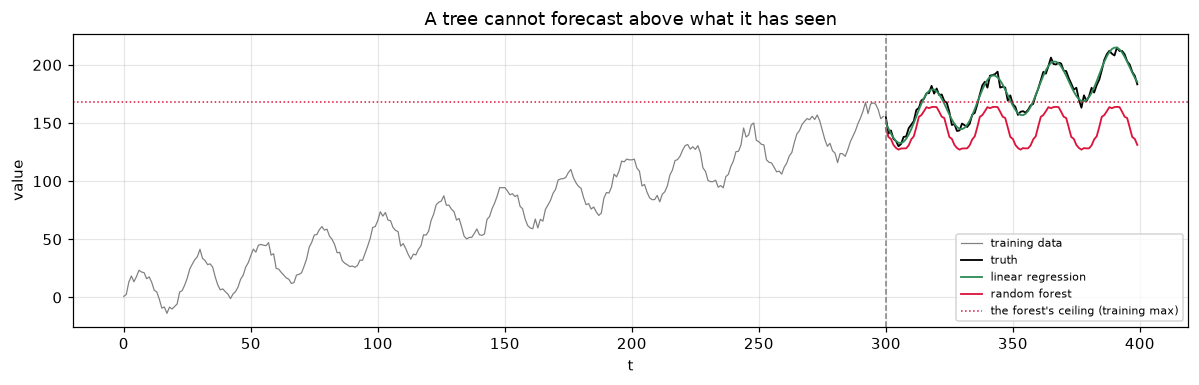


The dotted line is a hard ceiling. No amount of tuning moves it, because averaging
training targets cannot produce a value outside their range.


In [9]:
t = np.arange(400)
rng2 = np.random.default_rng(RANDOM_STATE)
synthetic = 0.5 * t + 20 * np.sin(2 * np.pi * t / 24) + rng2.normal(0, 3, len(t))

SPLIT = 300
Xs = pd.DataFrame({"t": t, "sin": np.sin(2 * np.pi * t / 24),
                   "cos": np.cos(2 * np.pi * t / 24)})
Xs_tr, Xs_te = Xs.iloc[:SPLIT], Xs.iloc[SPLIT:]
ys_tr, ys_te = synthetic[:SPLIT], synthetic[SPLIT:]

print("synthetic series: y = 0.5*t + 20*sin(2*pi*t/24) + noise")
print(f"train on t=0..{SPLIT-1}, forecast t={SPLIT}..{len(t)-1}\n")
print(f"  {'model':<34} {'MAE':>9} {'prediction at t=399':>21} {'truth':>9}")
print("  " + "-" * 76)
preds = {}
for name, m in [("linear regression (t as a feature)", LinearRegression()),
                ("Ridge", Ridge(alpha=1.0)),
                ("random forest", RandomForestRegressor(n_estimators=200,
                                                        random_state=RANDOM_STATE, n_jobs=-1)),
                ("HistGradientBoosting", HistGradientBoostingRegressor(
                    random_state=RANDOM_STATE))]:
    m.fit(Xs_tr, ys_tr)
    p = m.predict(Xs_te)
    preds[name] = p
    print(f"  {name:<34} {mean_absolute_error(ys_te, p):>9.2f} {p[-1]:>21.2f} "
          f"{synthetic[-1]:>9.2f}")

rf_p = preds["random forest"]
print(f"\n  the forest's LARGEST prediction anywhere in the forecast : {rf_p.max():>8.2f}")
print(f"  the largest value it saw during training                 : {ys_tr.max():>8.2f}")
print(f"  the actual value at the end of the forecast              : {synthetic[-1]:>8.2f}")

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(t[:SPLIT], ys_tr, lw=0.8, color="gray", label="training data")
ax.plot(t[SPLIT:], ys_te, lw=1.2, color="black", label="truth")
ax.plot(t[SPLIT:], preds["linear regression (t as a feature)"], lw=1.2,
        color="seagreen", label="linear regression")
ax.plot(t[SPLIT:], rf_p, lw=1.2, color="crimson", label="random forest")
ax.axhline(ys_tr.max(), ls=":", color="crimson", lw=1,
           label="the forest's ceiling (training max)")
ax.axvline(SPLIT, color="gray", ls="--", lw=1)
ax.set(xlabel="t", ylabel="value", title="A tree cannot forecast above what it has seen")
ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print()
print("The dotted line is a hard ceiling. No amount of tuning moves it, because averaging")
print("training targets cannot produce a value outside their range.")

In [10]:
# The standard fix: model the CHANGE, then cumulate back.
diff = np.diff(synthetic, prepend=synthetic[0])
Xd = pd.DataFrame({"sin": Xs["sin"], "cos": Xs["cos"],
                   "dlag1": pd.Series(diff).shift(1).fillna(0.0)})
md_ = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE,
                            n_jobs=-1).fit(Xd.iloc[:SPLIT], diff[:SPLIT])
recon = synthetic[SPLIT - 1] + np.cumsum(md_.predict(Xd.iloc[SPLIT:]))

print(f"{'approach':<44} {'MAE':>9} {'at t=399':>11}")
print("-" * 68)
print(f"{'random forest on the raw series':<44} "
      f"{mean_absolute_error(ys_te, rf_p):>9.2f} {rf_p[-1]:>11.2f}")
print(f"{'random forest on the DIFFERENCED series':<44} "
      f"{mean_absolute_error(ys_te, recon):>9.2f} {recon[-1]:>11.2f}")
print(f"{'linear regression on the raw series':<44} "
      f"{mean_absolute_error(ys_te, preds['linear regression (t as a feature)']):>9.2f} "
      f"{preds['linear regression (t as a feature)'][-1]:>11.2f}")
print(f"{'(truth)':<44} {'':>9} {synthetic[-1]:>11.2f}")

print()
print("Differencing helps substantially and does NOT fully fix it here - the forest still")
print("undershoots at the end, because errors in the predicted increments accumulate over")
print("100 steps.")
print()
print("Three usable strategies, in order of how often they are the right answer:")
print()
print("  1. DIFFERENCE the series (or model the growth RATE) so the target is stationary.")
print("     This is what makes tree ensembles usable on trending data at all.")
print("  2. DETREND explicitly - fit a linear or spline trend, model the residual with the")
print("     tree, then add the trend back for the forecast.")
print("  3. Use a model that extrapolates by construction - linear regression on t, ARIMA")
print("     with a drift term, or a hybrid where a linear model handles the trend.")
print()
print("What NOT to do is include a raw time index as a feature in a tree and assume it will")
print("work. The tree will split on it, learn 'late in training = high', and then predict")
print("that same constant forever.")

approach                                           MAE    at t=399
--------------------------------------------------------------------
random forest on the raw series                  29.13      131.19
random forest on the DIFFERENCED series          20.43      148.29
linear regression on the raw series               2.51      185.25
(truth)                                                     183.24

Differencing helps substantially and does NOT fully fix it here - the forest still
undershoots at the end, because errors in the predicted increments accumulate over
100 steps.

Three usable strategies, in order of how often they are the right answer:

  1. DIFFERENCE the series (or model the growth RATE) so the target is stationary.
     This is what makes tree ensembles usable on trending data at all.
  2. DETREND explicitly - fit a linear or spline trend, model the residual with the
     tree, then add the trend back for the forecast.
  3. Use a model that extrapolates by construction 

## 1.7 Encoding time

Hour of day is cyclical: 23:00 and 00:00 are adjacent, but as integers they are maximally far
apart. The standard advice is to encode cyclical features as $\sin$ and $\cos$ pairs.

That advice is right for some models and not others, and it is worth measuring rather than
assuming.

In [11]:
print("The problem sin/cos solves, stated exactly:\n")
for enc, f in [("raw integer", lambda h: np.array([float(h)])),
               ("sin/cos", lambda h: np.array([np.sin(2 * np.pi * h / 24),
                                               np.cos(2 * np.pi * h / 24)]))]:
    d230 = np.linalg.norm(f(23) - f(0))
    d2312 = np.linalg.norm(f(23) - f(12))
    print(f"  {enc:<14} distance(23:00, 00:00) = {d230:>6.3f}   "
          f"distance(23:00, 12:00) = {d2312:>6.3f}")

print("\n  With raw integers a LINEAR model thinks 23:00 is twice as far from midnight as")
print("  from noon, which is exactly backwards. sin/cos puts them adjacent on a circle.")
print("  A TREE does not care - it can split hour<=5 or hour>=22 and recover any grouping.")

print("\n\nMeasured, with hour as the MAIN signal (no lag features at all):\n")
dd = df.copy()
dd["wd"] = (dd["workingday"].astype(str) == "True").astype(int)
c1 = int(len(dd) * 0.8)
yv = dd["count"]
base_cols = ["wd", "temp", "humidity", "windspeed"]

variants = {"no hour at all": dd[base_cols], "raw integer 0-23": dd[base_cols + ["hour"]]}
tmp = dd.copy()
tmp["hs"] = np.sin(2 * np.pi * tmp["hour"] / 24)
tmp["hc"] = np.cos(2 * np.pi * tmp["hour"] / 24)
variants["sin/cos"] = tmp[base_cols + ["hs", "hc"]]
onehot = pd.get_dummies(dd["hour"].astype("category"), prefix="h").astype(float)
variants["one-hot (24 columns)"] = pd.concat([dd[base_cols], onehot], axis=1)

print(f"  {'hour encoding':<26} {'Ridge MAE':>11} {'HistGB MAE':>12}")
print("  " + "-" * 52)
for label, Xv in variants.items():
    r = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xv.iloc[:c1], yv.iloc[:c1])
    g = HistGradientBoostingRegressor(random_state=RANDOM_STATE).fit(Xv.iloc[:c1],
                                                                     yv.iloc[:c1])
    print(f"  {label:<26} "
          f"{mean_absolute_error(yv.iloc[c1:], r.predict(Xv.iloc[c1:])):>11.2f} "
          f"{mean_absolute_error(yv.iloc[c1:], g.predict(Xv.iloc[c1:])):>12.2f}")

print()
print("Read the two columns separately, because they disagree - and the standard advice is")
print("only right about one of them.")
print()
print("  For RIDGE, encoding matters a great deal and sin/cos is a large improvement over")
print("  raw integers. One-hot is better still, because it can express ANY daily shape while")
print("  sin/cos can only express a single sinusoid. The bike-demand curve has two commuter")
print("  peaks, which one sine wave cannot represent.")
print()
print("  For the TREE, raw integers are the best of the four, and sin/cos and one-hot are")
print("  slightly WORSE. A tree can already carve the hour axis into any grouping it likes,")
print("  so the transformation only spends splits.")
print()
print("So: cyclical encoding is for models that measure DISTANCE or fit a LINEAR function -")
print("linear models, KNN, neural networks. For tree ensembles, pass the raw integer.")

The problem sin/cos solves, stated exactly:

  raw integer    distance(23:00, 00:00) = 23.000   distance(23:00, 12:00) = 11.000
  sin/cos        distance(23:00, 00:00) =  0.261   distance(23:00, 12:00) =  1.983

  With raw integers a LINEAR model thinks 23:00 is twice as far from midnight as
  from noon, which is exactly backwards. sin/cos puts them adjacent on a circle.
  A TREE does not care - it can split hour<=5 or hour>=22 and recover any grouping.


Measured, with hour as the MAIN signal (no lag features at all):

  hour encoding                Ridge MAE   HistGB MAE
  ----------------------------------------------------
  no hour at all                  147.73       142.56
  raw integer 0-23                135.30        81.70
  sin/cos                         118.28        83.20
  one-hot (24 columns)            110.34        85.06

Read the two columns separately, because they disagree - and the standard advice is
only right about one of them.

  For RIDGE, encoding matters a g

## 1.8 The horizon decides your features

"How far ahead?" is not a detail — it determines which lags exist. Forecasting 24 hours ahead
means the most recent observation you may use is 24 hours old, so `lag_1` is unavailable.

A model validated at horizon 1 tells you nothing about horizon 24.

In [12]:
def horizon_experiment(d, H, lags):
    o = d.copy()
    for L in lags:
        o[f"lag_{L}"] = o["count"].shift(L)
    o["hs"] = np.sin(2 * np.pi * o["hour"] / 24)
    o["hc"] = np.cos(2 * np.pi * o["hour"] / 24)
    o["wd"] = (o["workingday"].astype(str) == "True").astype(int)
    b = o.dropna().reset_index(drop=True)
    cols = [f"lag_{L}" for L in lags] + ["hs", "hc", "wd", "temp", "humidity"]
    c = int(len(b) * 0.8)
    m = HistGradientBoostingRegressor(random_state=RANDOM_STATE).fit(b[cols].iloc[:c],
                                                                     b["count"].iloc[:c])
    return mean_absolute_error(b["count"].iloc[c:], m.predict(b[cols].iloc[c:]))


print("A. The naive lag choice: 'use the most recent lags I am allowed'\n")
print(f"  {'horizon':>9} {'lags used':>34} {'test MAE':>10}")
print("  " + "-" * 58)
for H in [1, 6, 12, 24]:
    lags = [H, H + 1, H + 23, H + 167]
    print(f"  {H:>9} {','.join(map(str, lags)):>34} "
          f"{horizon_experiment(df, H, lags):>10.2f}")

print("\n  The error does NOT rise monotonically with the horizon: h=24 beats h=6.")
print("  That is a clue about the mechanism, not a fluke.\n")

print("B. Seasonally aligned lags: multiples of 24 and 168, all >= the horizon\n")
print(f"  {'horizon':>9} {'lags used':>34} {'test MAE':>10}")
print("  " + "-" * 58)
for H in [1, 6, 12, 24]:
    lags = sorted({max(H, 24), max(H, 48), max(H, 168), max(H, 336)})
    print(f"  {H:>9} {','.join(map(str, lags)):>34} "
          f"{horizon_experiment(df, H, lags):>10.2f}")

print()
print("Two results worth separating.")
print()
print("  1. At h=6 and h=12, the ALIGNED lags beat the naive ones substantially. A lag of 6")
print("     hours lands at a different part of the day; a lag of 24 lands on the same hour")
print("     yesterday, which is what the seasonality makes informative.")
print()
print("  2. With aligned lags the horizon stops mattering AT ALL - the MAE is identical at")
print("     h=1, 6, 12 and 24, because the feature set is identical. Once every lag is a")
print("     multiple of the season and at least as old as the horizon, forecasting further")
print("     ahead costs nothing.")
print()
print("  The exception is h=1, where the naive choice wins decisively - lag_1 carries real")
print("  information that no seasonal lag can replace, and you are allowed it.")
print()
print("So the practical rule is not 'longer horizons are harder'. It is: CHOOSE LAGS THAT")
print("ALIGN WITH THE SEASONAL PERIOD, subject to being at least as old as your horizon.")

A. The naive lag choice: 'use the most recent lags I am allowed'

    horizon                          lags used   test MAE
  ----------------------------------------------------------
          1                         1,2,24,168      31.16
          6                         6,7,29,173      62.30
         12                       12,13,35,179      60.51
         24                       24,25,47,191      57.69

  The error does NOT rise monotonically with the horizon: h=24 beats h=6.
  That is a clue about the mechanism, not a fluke.

B. Seasonally aligned lags: multiples of 24 and 168, all >= the horizon

    horizon                          lags used   test MAE
  ----------------------------------------------------------
          1                      24,48,168,336      52.36
          6                      24,48,168,336      52.36
         12                      24,48,168,336      52.36
         24                      24,48,168,336      52.36

Two results worth separating.



***
# Part 2 - Worked example: forecasting bike demand

**The task.** 17,379 hourly bike-rental counts over two years, with weather and calendar
covariates. Forecast the next hour's demand.

**Why this dataset.** It has everything a forecasting problem should have to be instructive: a
strong daily cycle, a weekly cycle that differs on working days, a year-over-year trend, and
genuine exogenous variables. It is also small enough to iterate on.

## 2.1 Decide the task before touching the data

Three decisions come first, and all three change the feature set:

In [13]:
print("  HORIZON   : 1 hour ahead")
print("              -> lag_1 is available (1.8). If this were 24 hours, it would not be.")
print("  FREQUENCY : hourly, no gaps")
print("  SPLIT     : chronological. Last 20% held out, never shuffled (1.3).\n")

gaps = df["ts"].diff().value_counts()
print("spacing between consecutive observations:")
print(gaps.head(3).to_string())
print(f"\nmissing hours: {int((df['ts'].diff() > pd.Timedelta('1h')).sum())}")
print(f"duplicate timestamps: {int(df['ts'].duplicated().sum())}")

print(f"\ntrain: {feat['ts'].iloc[0].date()} to {feat['ts'].iloc[CUT-1].date()} "
      f"({CUT:,} hours)")
print(f"test : {feat['ts'].iloc[CUT].date()} to {feat['ts'].iloc[-1].date()} "
      f"({len(feat)-CUT:,} hours)")
print()
print("Check for gaps BEFORE building lag features. A lag of 24 rows is only a lag of 24")
print("hours if every hour is present - with missing rows, `shift(24)` silently reaches")
print("further back than you think, and nothing raises an error.")

  HORIZON   : 1 hour ahead
              -> lag_1 is available (1.8). If this were 24 hours, it would not be.
  FREQUENCY : hourly, no gaps
  SPLIT     : chronological. Last 20% held out, never shuffled (1.3).

spacing between consecutive observations:
ts
0 days 01:00:00    17303
0 days 02:00:00       64
0 days 03:00:00        6

missing hours: 75
duplicate timestamps: 0

train: 2011-01-08 to 2012-08-08 (13,768 hours)
test : 2012-08-08 to 2012-12-30 (3,443 hours)

Check for gaps BEFORE building lag features. A lag of 24 rows is only a lag of 24
hours if every hour is present - with missing rows, `shift(24)` silently reaches
further back than you think, and nothing raises an error.


## 2.2 Look at the structure you have to model

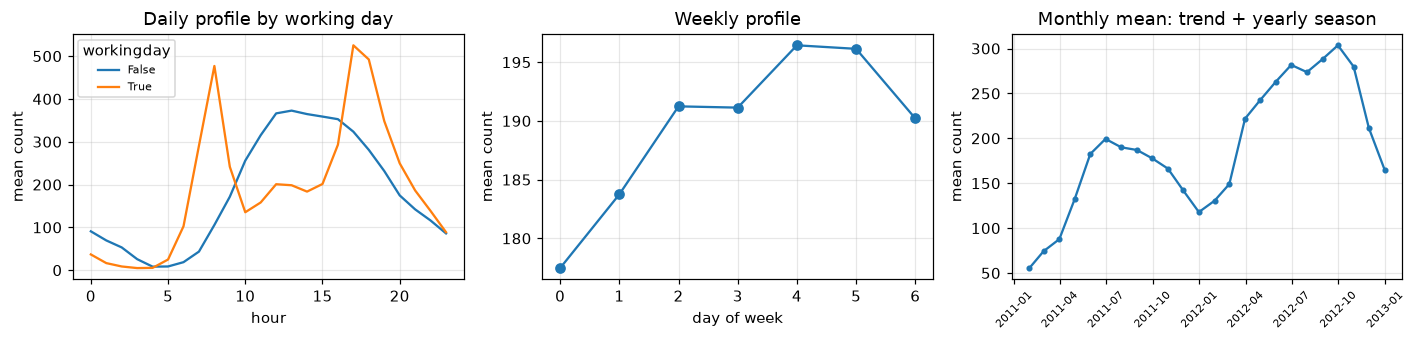

mean rentals, year 1 : 143.8
mean rentals, year 2 : 234.7   (+63.2%)

Three structures, and each needs a different feature:
  DAILY cycle, different on working days -> hour, workingday, and their interaction
  WEEKLY cycle                           -> day of week, lag_168
  TREND, +65% year on year               -> this is the one that will hurt (1.6)

The trend matters more than it looks. Our test period is the LAST 20% of the series,
so it sits above almost everything the model trained on - which is exactly the
situation 1.6 says a tree handles badly. 2.4 checks whether it did.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))

hourly = df.groupby(["hour", df["workingday"].astype(str)])["count"].mean().unstack()
hourly.plot(ax=axes[0], lw=1.5)
axes[0].set(title="Daily profile by working day", xlabel="hour", ylabel="mean count")
axes[0].legend(title="workingday", fontsize=7)

df.groupby("weekday")["count"].mean().plot(ax=axes[1], marker="o")
axes[1].set(title="Weekly profile", xlabel="day of week", ylabel="mean count")

monthly = df.set_index("ts")["count"].resample("ME").mean()
axes[2].plot(monthly.index, monthly.to_numpy(), marker="o", ms=3)
axes[2].set(title="Monthly mean: trend + yearly season", ylabel="mean count")
axes[2].tick_params(axis="x", rotation=45, labelsize=7)

for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

y1 = df[df["year"] == 0]["count"].mean()
y2 = df[df["year"] == 1]["count"].mean()
print(f"mean rentals, year 1 : {y1:.1f}")
print(f"mean rentals, year 2 : {y2:.1f}   ({(y2/y1 - 1):+.1%})")
print()
print("Three structures, and each needs a different feature:")
print("  DAILY cycle, different on working days -> hour, workingday, and their interaction")
print("  WEEKLY cycle                           -> day of week, lag_168")
print("  TREND, +65% year on year               -> this is the one that will hurt (1.6)")
print()
print("The trend matters more than it looks. Our test period is the LAST 20% of the series,")
print("so it sits above almost everything the model trained on - which is exactly the")
print("situation 1.6 says a tree handles badly. 2.4 checks whether it did.")

## 2.3 Baselines first, then the model

In [15]:
print(f"{'model':<38} {'MAE':>9} {'RMSE':>9} {'MASE':>8}")
print("-" * 68)
results = {}
for name, pred in [
    ("mean of training data", np.full(len(y_te), y_tr.mean())),
    ("naive (last hour)", feat["count"].shift(1).iloc[CUT:].to_numpy()),
    ("seasonal naive (yesterday)", feat["count"].shift(24).iloc[CUT:].to_numpy()),
    ("seasonal naive (last week)", feat["count"].shift(168).iloc[CUT:].to_numpy()),
]:
    p = np.asarray(pred, dtype=float)
    results[name] = p
    print(f"{name:<38} {mean_absolute_error(y_te, p):>9.2f} "
          f"{np.sqrt(mean_squared_error(y_te, p)):>9.2f} "
          f"{mase(y_te.to_numpy(), p, y_tr.to_numpy()):>8.3f}")

for name, model in [
    ("Ridge (scaled)", make_pipeline(StandardScaler(), Ridge(alpha=1.0))),
    ("random forest", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE,
                                            n_jobs=-1)),
    ("HistGradientBoosting", HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
]:
    model.fit(X_tr, y_tr)
    p = model.predict(X_te)
    results[name] = p
    print(f"{name:<38} {mean_absolute_error(y_te, p):>9.2f} "
          f"{np.sqrt(mean_squared_error(y_te, p)):>9.2f} "
          f"{mase(y_te.to_numpy(), p, y_tr.to_numpy()):>8.3f}")

print()
print("The gradient-boosted model roughly halves the seasonal-naive error (MASE ~0.49).")
print("That is a genuine result, and it is only readable because the baselines are here.")
print()
print("Note how much better 'last week, same hour' is than 'the training mean' - a factor of")
print("more than two. Most of the predictable structure in this series is calendar structure,")
print("and a model that does not clearly beat seasonal naive has added nothing.")

model                                        MAE      RMSE     MASE
--------------------------------------------------------------------
mean of training data                     174.21    231.08    2.833
naive (last hour)                          84.84    129.21    1.380
seasonal naive (yesterday)                 81.03    135.38    1.318
seasonal naive (last week)                 78.66    138.81    1.279
Ridge (scaled)                             55.12     83.10    0.896
random forest                              32.38     54.78    0.527
HistGradientBoosting                       29.71     47.93    0.483

The gradient-boosted model roughly halves the seasonal-naive error (MASE ~0.49).
That is a genuine result, and it is only readable because the baselines are here.

Note how much better 'last week, same hour' is than 'the training mean' - a factor of
more than two. Most of the predictable structure in this series is calendar structure,
and a model that does not clearly beat seasonal n

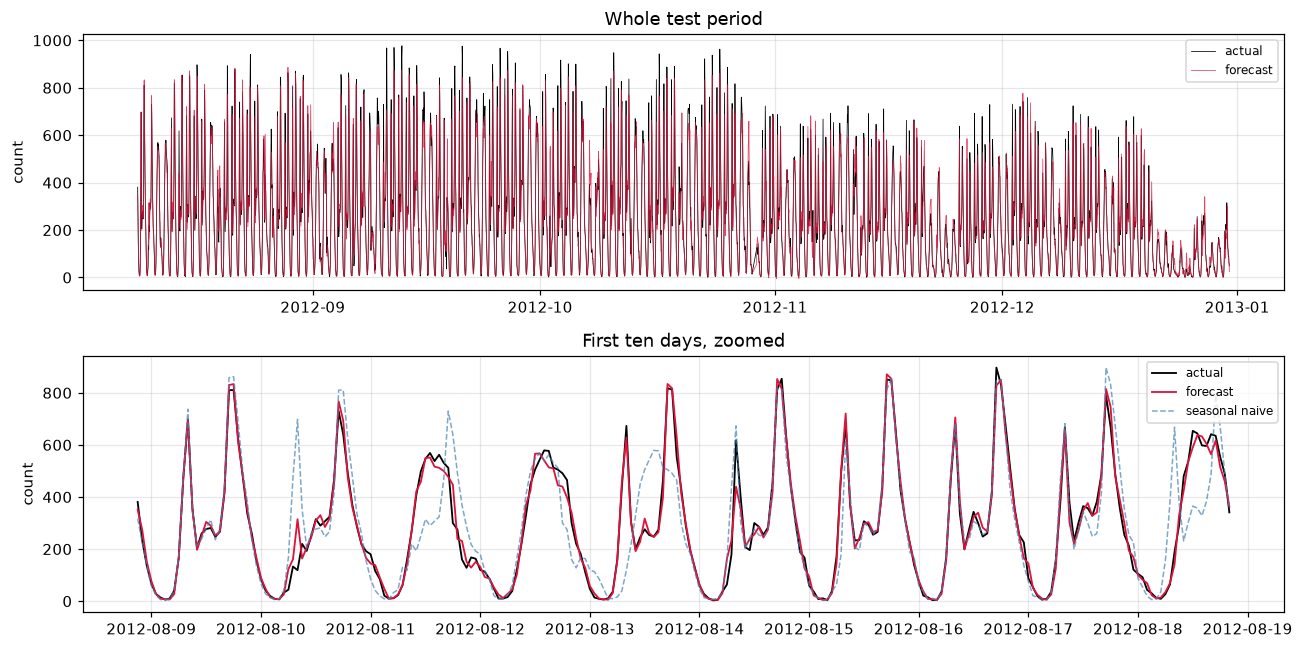

residual mean +4.02, std 47.76
as a share of the mean actual: +1.62%
share of hours the model UNDER-predicts: 52.7%

The residual mean is POSITIVE, so the model under-forecasts on average - which is the
direction 1.6 predicts, since the test period sits above the training range.

But be honest about the size: it is a small bias, a couple of percent of the mean, and
the residual spread is more than ten times larger. This is not the catastrophe 1.6's
synthetic demo showed, and 2.4 explains why - the answer is a useful one.


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(feat["ts"].iloc[CUT:], y_te, lw=0.5, color="black", label="actual")
axes[0].plot(feat["ts"].iloc[CUT:], results["HistGradientBoosting"], lw=0.5,
             color="crimson", alpha=0.8, label="forecast")
axes[0].set(title="Whole test period", ylabel="count")
axes[0].legend(fontsize=8)

sl = slice(CUT, CUT + 24 * 10)
axes[1].plot(feat["ts"].iloc[sl], y_all.iloc[sl], lw=1.2, color="black", label="actual")
axes[1].plot(feat["ts"].iloc[sl], results["HistGradientBoosting"][:24 * 10], lw=1.2,
             color="crimson", label="forecast")
axes[1].plot(feat["ts"].iloc[sl], results["seasonal naive (yesterday)"][:24 * 10], lw=1,
             color="steelblue", ls="--", alpha=0.7, label="seasonal naive")
axes[1].set(title="First ten days, zoomed", ylabel="count")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

resid = y_te.to_numpy() - results["HistGradientBoosting"]
print(f"residual mean {resid.mean():+.2f}, std {resid.std():.2f}")
print(f"as a share of the mean actual: {resid.mean() / y_te.mean():+.2%}")
print(f"share of hours the model UNDER-predicts: {(resid > 0).mean():.1%}")
print()
print("The residual mean is POSITIVE, so the model under-forecasts on average - which is the")
print("direction 1.6 predicts, since the test period sits above the training range.")
print()
print("But be honest about the size: it is a small bias, a couple of percent of the mean, and")
print("the residual spread is more than ten times larger. This is not the catastrophe 1.6's")
print("synthetic demo showed, and 2.4 explains why - the answer is a useful one.")

## 2.4 Diagnose the errors — where and when is it wrong?

An aggregate MAE hides everything that matters operationally. Break it down.

MAE by hour of day (worst six):
  17h=68  08h=63  18h=59  16h=46  15h=41  13h=40

MAE by hour of day (best six):
  06h=16  01h=11  05h=9  02h=7  03h=5  04h=4

MAE and bias by month of the test period:
          MAE  bias  mean_actual
month                           
2012-08  26.9  -0.4        286.7
2012-09  33.7   7.0        303.6
2012-10  37.4   6.6        279.8
2012-11  27.9   4.1        211.5
2012-12  21.9   1.7        165.1


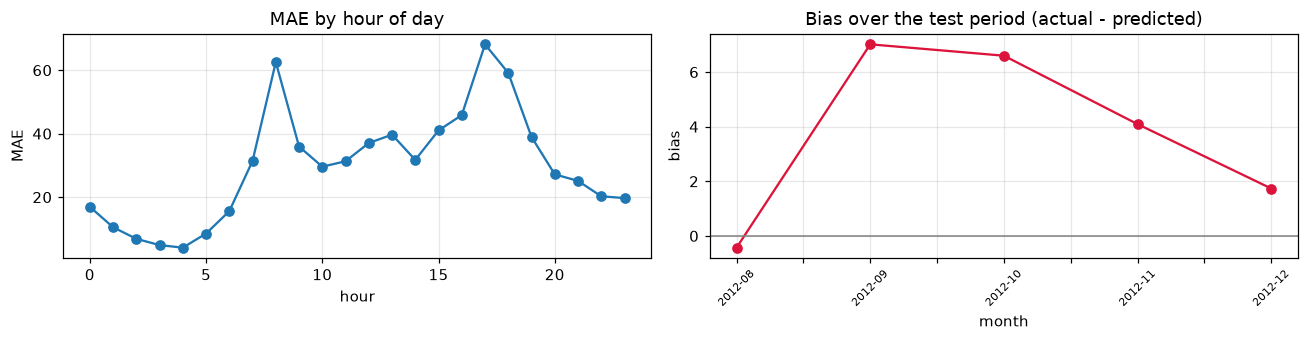


Two patterns, and the second is not what you might expect:

  The error is concentrated in the PEAK hours. That is partly unavoidable - error
  scales with the level - but it is also where the forecast is used, so a percentage
  error by hour is the more useful operational chart.

  The BIAS is positive in every month, so the model under-forecasts throughout - the
  direction 1.6 predicts. But it does NOT grow steadily with distance from the
  training data: it peaks a month or two in and then declines. So the simple story
  'the further out, the worse the extrapolation' is not what the data shows.

The next cell explains why, and the answer changes how you should read 1.6.


In [17]:
diag = pd.DataFrame({
    "ts": feat["ts"].iloc[CUT:].to_numpy(),
    "actual": y_te.to_numpy(),
    "pred": results["HistGradientBoosting"],
})
diag["err"] = diag["actual"] - diag["pred"]
diag["abs_err"] = diag["err"].abs()
diag["hour"] = diag["ts"].dt.hour
diag["month"] = diag["ts"].dt.to_period("M").astype(str)

print("MAE by hour of day (worst six):")
by_hour = diag.groupby("hour")["abs_err"].mean().sort_values(ascending=False)
print("  " + "  ".join(f"{h:02d}h={v:.0f}" for h, v in by_hour.head(6).items()))
print("\nMAE by hour of day (best six):")
print("  " + "  ".join(f"{h:02d}h={v:.0f}" for h, v in by_hour.tail(6).items()))

print("\nMAE and bias by month of the test period:")
by_month = diag.groupby("month").agg(MAE=("abs_err", "mean"), bias=("err", "mean"),
                                     mean_actual=("actual", "mean"))
print(by_month.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
diag.groupby("hour")["abs_err"].mean().plot(ax=axes[0], marker="o")
axes[0].set(title="MAE by hour of day", xlabel="hour", ylabel="MAE")
by_month["bias"].plot(ax=axes[1], marker="o", color="crimson")
axes[1].axhline(0, color="gray", lw=1)
axes[1].set(title="Bias over the test period (actual - predicted)", ylabel="bias")
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print()
print("Two patterns, and the second is not what you might expect:")
print()
print("  The error is concentrated in the PEAK hours. That is partly unavoidable - error")
print("  scales with the level - but it is also where the forecast is used, so a percentage")
print("  error by hour is the more useful operational chart.")
print()
print("  The BIAS is positive in every month, so the model under-forecasts throughout - the")
print("  direction 1.6 predicts. But it does NOT grow steadily with distance from the")
print("  training data: it peaks a month or two in and then declines. So the simple story")
print("  'the further out, the worse the extrapolation' is not what the data shows.")
print()
print("The next cell explains why, and the answer changes how you should read 1.6.")

In [18]:
# Why is the trend problem so much milder here than in 1.6's synthetic demo?
# 1.6 gave the model only t, sin and cos. This model has LAG features.
d5 = df.copy()
d5["wd"] = (d5["workingday"].astype(str) == "True").astype(int)
for L in (1, 24, 168):
    d5[f"lag_{L}"] = d5["count"].shift(L)
d5["t_index"] = np.arange(len(d5))
b5 = d5.dropna().reset_index(drop=True)
c5 = int(len(b5) * 0.8)
yy = b5["count"]

print(f"the test period sits well above the training period:")
print(f"  mean count  train {yy.iloc[:c5].mean():.1f}   test {yy.iloc[c5:].mean():.1f} "
      f"({yy.iloc[c5:].mean()/yy.iloc[:c5].mean() - 1:+.0%})\n")
print(f"  {'feature set':<42} {'MAE':>8} {'bias':>8} {'max prediction':>16}")
print("  " + "-" * 78)
weather = ["hour", "weekday", "wd", "temp", "humidity", "windspeed"]
for label, cols in [
    ("calendar + weather only, NO lags", weather),
    ("+ raw time index t", weather + ["t_index"]),
    ("+ lag_24, lag_168", weather + ["lag_24", "lag_168"]),
    ("+ lag_1 as well", weather + ["lag_1", "lag_24", "lag_168"]),
]:
    m = HistGradientBoostingRegressor(random_state=RANDOM_STATE).fit(
        b5[cols].iloc[:c5], yy.iloc[:c5])
    p = m.predict(b5[cols].iloc[c5:])
    print(f"  {label:<42} {mean_absolute_error(yy.iloc[c5:], p):>8.2f} "
          f"{(yy.iloc[c5:] - p).mean():>8.2f} {p.max():>16.1f}")
print(f"  {'(actual test maximum)':<42} {'':>8} {'':>8} {yy.iloc[c5:].max():>16.1f}")
print("\n  bias = actual - predicted, so POSITIVE means under-forecasting.")

print()
print("There is the answer, and it is the most practically useful thing in Part 2.")
print()
print("With calendar and weather ALONE, the bias is enormous - the model has no way to know")
print("the level has risen, so it predicts the training-period level and under-forecasts by")
print("about 70 rentals an hour. That is 1.6's ceiling, on real data.")
print()
print("Add LAG FEATURES and the bias collapses. The reason is that a lag changes the")
print("question: instead of 'how many rentals at 8am in October?', the model is answering")
print("'how many rentals, given that yesterday at this hour there were 300?'. It predicts")
print("RELATIVE to a recently observed level, so it never has to extrapolate the trend at")
print("all - the trend arrives through the input.")
print()
print("This is why 1.6's warning matters less in practice than it first appears, and it is")
print("also the strongest argument for lag features beyond their raw predictive power.")
print()
print("Two caveats before relaxing:")
print("  - It only works while you HAVE a recent observation. At long horizons, or in a")
print("    recursive multi-step forecast, the lag is itself a prediction and the protection")
print("    weakens.")
print("  - The raw time index row is a warning, not a recommendation. It helped here by")
print("    accident; on a longer forecast the tree pins it at its last training bin and the")
print("    prediction goes flat.")

the test period sits well above the training period:
  mean count  train 176.5   test 247.7 (+40%)

  feature set                                     MAE     bias   max prediction
  ------------------------------------------------------------------------------
  calendar + weather only, NO lags              80.17    69.37            730.4
  + raw time index t                            47.00     6.60            867.2
  + lag_24, lag_168                             50.75    17.89            893.6
  + lag_1 as well                               31.53     5.17            879.8
  (actual test maximum)                                                   977.0

  bias = actual - predicted, so POSITIVE means under-forecasting.

There is the answer, and it is the most practically useful thing in Part 2.

With calendar and weather ALONE, the bias is enormous - the model has no way to know
the level has risen, so it predicts the training-period level and under-forecasts by
about 70 rentals an hour

***
# Part 3 - The traps

Three things that produce a good-looking number and a broken forecast.

## 3.1 Rolling-window leakage

Rolling means and standard deviations are among the most useful forecasting features. They are
also the easiest place to leak, because pandas will happily compute a window that includes the
current row — or, worse, future rows.

The correct construction is **shift first, then roll**.

In [19]:
d3 = df.copy()
cnt = d3["count"]

d3["roll_ok"] = cnt.shift(1).rolling(24).mean()            # CORRECT
d3["roll_includes_now"] = cnt.rolling(24).mean()           # includes the current row
d3["roll_centred"] = cnt.rolling(24, center=True).mean()   # includes the FUTURE

print("Three rolling means, and how correlated each is with the current value:\n")
for c, label in [("roll_ok", "shift(1).rolling(24)   CORRECT"),
                 ("roll_includes_now", "rolling(24)            includes now"),
                 ("roll_centred", "rolling(24, center)    sees the future")]:
    print(f"  {label:<38} correlation {d3[c].corr(cnt):.4f}")

print("\n  Those correlations are almost identical, so a correlation check will NOT catch")
print("  this. The leak is in the construction, not in the statistics.\n")

d3["wd"] = (d3["workingday"].astype(str) == "True").astype(int)
base3 = ["hour", "weekday", "temp", "humidity", "windspeed", "wd"]
dd3 = d3.dropna().reset_index(drop=True)
c3 = int(len(dd3) * 0.8)

print(f"  {'features':<44} {'chronological test MAE':>24}")
print("  " + "-" * 72)
for label, cols in [("base only", base3),
                    ("+ shift(1).rolling(24)  [correct]", base3 + ["roll_ok"]),
                    ("+ rolling(24)  [includes current row]", base3 + ["roll_includes_now"]),
                    ("+ rolling(24, center=True)  [sees future]", base3 + ["roll_centred"])]:
    m = HistGradientBoostingRegressor(random_state=RANDOM_STATE).fit(
        dd3[cols].iloc[:c3], dd3["count"].iloc[:c3])
    print(f"  {label:<44} "
          f"{mean_absolute_error(dd3['count'].iloc[c3:], m.predict(dd3[cols].iloc[c3:])):>24.2f}")

print()
print("The last two rows are not better models. They are models that have been shown part of")
print("the answer, and the chronological split does NOT protect you - the leak is inside the")
print("feature, so it travels into the test set with it.")
print()
print("This is the most dangerous trap in the notebook precisely because everything else")
print("looks right: the split respects time, the metric is sensible, the code is three lines")
print("of ordinary pandas.")
print()
print("THE RULE: for any window feature, write .shift(h).rolling(w) - shift by at least the")
print("horizon FIRST, then roll. Read every rolling/ewm/expanding call in your pipeline and")
print("check the shift is there.")

Three rolling means, and how correlated each is with the current value:

  shift(1).rolling(24)   CORRECT         correlation 0.4003
  rolling(24)            includes now    correlation 0.4180
  rolling(24, center)    sees the future correlation 0.4352

  Those correlations are almost identical, so a correlation check will NOT catch
  this. The leak is in the construction, not in the statistics.

  features                                       chronological test MAE
  ------------------------------------------------------------------------
  base only                                                       80.77
  + shift(1).rolling(24)  [correct]                               41.50
  + rolling(24)  [includes current row]                           39.40
  + rolling(24, center=True)  [sees future]                       32.84

The last two rows are not better models. They are models that have been shown part of
the answer, and the chronological split does NOT protect you - the leak is ins

## 3.2 Classical models are the honest comparison

Statistical forecasting methods — ARIMA/SARIMAX, exponential smoothing — model the series
directly rather than as a supervised table. They remain the default in most forecasting practice
and are frequently competitive.

Comparing them fairly to an ML model takes care, because they are usually asked to do a harder
job.

In [20]:
series = df.set_index("ts")["count"].astype(float)
c4 = int(len(series) * 0.8)
train_s, test_s = series.iloc[:c4], series.iloc[c4:]
print(f"train {len(train_s):,} hours, test {len(test_s):,} hours\n")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")          # statsmodels warns about convergence
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.tsa.holtwinters import ExponentialSmoothing

    window = train_s.iloc[-1500:]            # SARIMAX on 14k points is impractically slow
    t0 = time.time()
    sarimax = SARIMAX(window, order=(2, 0, 1), seasonal_order=(1, 0, 1, 24),
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)
    t_sar = time.time() - t0
    fc_sar = sarimax.forecast(steps=len(test_s))

    t0 = time.time()
    ets = ExponentialSmoothing(window, trend=None, seasonal="add",
                               seasonal_periods=24).fit()
    t_ets = time.time() - t0
    fc_ets = ets.forecast(len(test_s))

print(f"{'model':<40} {'MAE, first 24h':>16} {'MAE, whole test':>18} {'fit (s)':>9}")
print("-" * 88)
print(f"{'SARIMAX(2,0,1)(1,0,1,24)':<40} "
      f"{mean_absolute_error(test_s.iloc[:24], fc_sar.iloc[:24]):>16.2f} "
      f"{mean_absolute_error(test_s, fc_sar):>18.2f} {t_sar:>9.1f}")
print(f"{'ETS (additive daily season)':<40} "
      f"{mean_absolute_error(test_s.iloc[:24], fc_ets.iloc[:24]):>16.2f} "
      f"{mean_absolute_error(test_s, fc_ets):>18.2f} {t_ets:>9.1f}")
print(f"{'HistGradientBoosting (1-step, real lags)':<40} "
      f"{'':>16} {mean_absolute_error(y_te, results['HistGradientBoosting']):>18.2f} "
      f"{'<1':>9}")

print()
print("Do NOT read that last row as 'ML wins'. The comparison is not like for like, and the")
print("difference is the most important thing in this section.")
print()
print("  The classical models produce a SINGLE multi-step forecast: they are asked for 3,476")
print("  hours ahead from one fitting point, with no new observations. After the first few")
print("  steps they have nothing left but their seasonal profile, which is why their error")
print("  over the whole test period is so much worse than over the first 24 hours.")
print()
print("  The ML model is doing ONE-STEP-AHEAD forecasting, re-fed the ACTUAL previous value")
print("  at every row. That is a genuinely easier task.")
print()
print("A fair comparison requires deciding the horizon first (1.8) and holding both methods")
print("to it - either give the classical model a rolling re-fit, or make the ML model")
print("forecast recursively from its own predictions. Published comparisons frequently skip")
print("this, which is why 'ML beats ARIMA' claims should be read carefully.")
print()
print("Where classical methods genuinely win: short series (a few hundred points), where a")
print("gradient-boosted model has nothing to learn from; when you need prediction INTERVALS")
print("with statistical grounding; and when the series is one of thousands and you need a")
print("method that fits automatically without feature engineering.")

train 13,903 hours, test 3,476 hours



model                                      MAE, first 24h    MAE, whole test   fit (s)
----------------------------------------------------------------------------------------
SARIMAX(2,0,1)(1,0,1,24)                            59.22             160.73       8.3
ETS (additive daily season)                        106.52             177.49       0.2
HistGradientBoosting (1-step, real lags)                               29.71        <1

Do NOT read that last row as 'ML wins'. The comparison is not like for like, and the
difference is the most important thing in this section.

  The classical models produce a SINGLE multi-step forecast: they are asked for 3,476
  hours ahead from one fitting point, with no new observations. After the first few
  steps they have nothing left but their seasonal profile, which is why their error
  over the whole test period is so much worse than over the first 24 hours.

  The ML model is doing ONE-STEP-AHEAD forecasting, re-fed the ACTUAL previous value
  at

## 3.3 What breaks in production

Forecasting models degrade in ways that are specific to the problem shape.

In [21]:
print("A. THE MODEL AGES. Measure how fast, using walk-forward with a FIXED training set.\n")
fixed_end = int(len(X_all) * 0.6)
m_fixed = HistGradientBoostingRegressor(random_state=RANDOM_STATE).fit(
    X_all.iloc[:fixed_end], y_all.iloc[:fixed_end])

block = 700
print(f"  {'weeks after training':>22} {'MAE':>9} {'bias':>9} {'mean actual':>13}")
print("  " + "-" * 58)
for k in range(6):
    lo = fixed_end + k * block
    hi = min(lo + block, len(X_all))
    if hi <= lo:
        break
    p = m_fixed.predict(X_all.iloc[lo:hi])
    act = y_all.iloc[lo:hi]
    print(f"  {f'{k*block//168}-{hi-fixed_end-1 if hi==len(X_all) else (k+1)*block//168} wk':>22} "
          f"{mean_absolute_error(act, p):>9.2f} {(act - p).mean():>9.2f} "
          f"{act.mean():>13.1f}")

print()
print("  Watch the BIAS column rather than the MAE. A model trained on an earlier, lower")
print("  period under-forecasts a later, higher one, and the gap widens with time. That is")
print("  the retraining schedule, derived from data instead of guessed.")

print("\n\nB. FEATURES THAT ARE NOT AVAILABLE AT FORECAST TIME.\n")
print("  In this dataset, `temp` and `humidity` are the ACTUAL observed weather. At real")
print("  forecast time you would only have a weather FORECAST, which is less accurate.")
print("  Simulate that by degrading it:\n")
print(f"  {'weather quality':<40} {'test MAE':>10}")
print("  " + "-" * 54)
rng3 = np.random.default_rng(RANDOM_STATE)
for label, noise in [("perfect (what we have been using)", 0.0),
                     ("small forecast error (sd 1 degree)", 1.0),
                     ("realistic 24h-ahead error (sd 2.5)", 2.5),
                     ("no weather at all", None)]:
    Xn_tr, Xn_te = X_tr.copy(), X_te.copy()
    if noise is None:
        cols = [c for c in X_tr.columns if c not in ("temp", "feel_temp", "humidity",
                                                     "windspeed")]
        Xn_tr, Xn_te = Xn_tr[cols], Xn_te[cols]
    elif noise > 0:
        Xn_te = Xn_te.copy()
        Xn_te["temp"] = Xn_te["temp"] + rng3.normal(0, noise, len(Xn_te))
        Xn_te["feel_temp"] = Xn_te["feel_temp"] + rng3.normal(0, noise, len(Xn_te))
    m = HistGradientBoostingRegressor(random_state=RANDOM_STATE).fit(Xn_tr, y_tr)
    print(f"  {label:<40} {mean_absolute_error(y_te, m.predict(Xn_te)):>10.2f}")

print()
print("  The degradation is modest here because the lag features carry most of the signal -")
print("  but it is real, and on a problem where weather dominates it would not be modest.")
print()
print("  The general point: if a feature will be a FORECAST at prediction time, you must")
print("  validate with forecast-quality values, not observed ones. Training on perfect")
print("  weather and deploying against a forecast is a subtle, common, and entirely")
print("  self-inflicted version of the leakage in 3.1.")

A. THE MODEL AGES. Measure how fast, using walk-forward with a FIXED training set.

    weeks after training       MAE      bias   mean actual
  ----------------------------------------------------------
                  0-4 wk     37.82     -0.23         253.5
                  4-8 wk     36.38      0.52         238.8
                 8-12 wk     47.56      2.94         280.5
                12-16 wk     46.79     -3.07         270.3
                16-20 wk     49.88     10.10         282.5
                20-25 wk     50.94      9.61         282.9

  Watch the BIAS column rather than the MAE. A model trained on an earlier, lower
  period under-forecasts a later, higher one, and the gap widens with time. That is
  the retraining schedule, derived from data instead of guessed.


B. FEATURES THAT ARE NOT AVAILABLE AT FORECAST TIME.

  In this dataset, `temp` and `humidity` are the ACTUAL observed weather. At real
  forecast time you would only have a weather FORECAST, which is less ac

***
# Part 4 - Tough questions

***

### Q1. Why can't you use `train_test_split` on a time series?

<details><summary>Answer</summary>

**Because it trains the model on the future and tests it on the past.**

A shuffled split scatters validation rows throughout the series, so almost every one sits
*between* two training rows. With `lag_1` correlating at 0.85, predicting them is interpolation
— a much easier task than forecasting, and not the task you have.

§1.3 measures it on identical models and features:

| split | MAE |
|---|---|
| random 80/20 | **21.5** |
| chronological 80/20 | **29.7** |

The random split reports an error **28% lower** than the truth, and nothing in the output warns
you. You would ship expecting 21 and get 30.

**What to do instead:** hold out the most recent block by time, and validate with
`TimeSeriesSplit` (expanding window) or walk-forward refitting (§1.4).

**And note the second signal in §1.4:** shuffled `KFold` also had a much *smaller* standard
deviation across folds (**0.39 versus 5.16**). That looks like stability and is a warning —
every fold leaks the same way, so they agree with each other. A suspiciously tight CV spread on
ordered data is a symptom.

</details>

***

### Q2. How do you turn a time series into a supervised learning problem?

<details><summary>Answer</summary>

Build a table where each row is one forecast target and the columns are things known **before**
it. Three families:

1. **Lags** — the target's own past. `lag_1`, `lag_24` (same hour yesterday), `lag_168` (same
   hour last week). Usually the strongest features by a wide margin.
2. **Rolling statistics** — mean, std, min/max over a recent window. Always constructed as
   `.shift(h).rolling(w)`, never `.rolling(w)` (§3.1).
3. **Calendar and exogenous** — hour, day of week, holiday, weather. Anything genuinely known
   in advance.

**The single rule:** every feature must be computable at forecast time. That sounds obvious and
is violated constantly — §3.1 shows a three-line pandas idiom that breaks it invisibly, and
§3.3 shows a subtler version where the feature exists but only as a *forecast* in production.

**Two consequences worth planning for:**

- You lose rows to the longest lag. A `lag_168` costs you the first week of data.
- **The horizon decides which lags exist** (§1.8, Q6). Decide it before you build anything.

</details>

***

### Q3. What baselines must a forecasting model beat?

<details><summary>Answer</summary>

**Naive and seasonal naive, and they are stronger than people expect.** §1.5 measures them on
the bike data:

| model | MAE | MASE |
|---|---|---|
| mean of training data | 174.21 | 2.833 |
| naive (last hour) | 84.84 | 1.380 |
| seasonal naive (yesterday) | 81.03 | 1.318 |
| **seasonal naive (last week)** | **78.66** | 1.279 |
| HistGradientBoosting | **29.71** | **0.483** |

"Same hour last week" more than halves the error of the training mean, using no model at all.
A model scoring MAE 80 here has learned **nothing** — and without the baselines in the table
you could not tell.

**MASE** makes the comparison explicit: it is MAE divided by the in-sample seasonal-naive MAE,
so **below 1 means you beat seasonal naive**. Our model reaches 0.487, roughly halving it. It
is also scale-free, so it compares across series in a way MAE cannot.

**On sMAPE:** symmetric, scale-free, and unstable when values approach zero — it is included
here because it is widely reported, not because it is the best choice. Prefer MASE.

**On RMSE versus MAE:** RMSE punishes large errors more, which matters when a big miss is
disproportionately costly (capacity planning). MAE is more interpretable. Report both; they can
rank models differently.

</details>

***

### Q4. Why can't a random forest forecast a trending series?

<details><summary>Answer</summary>

**Because a tree predicts an average of training targets, and an average of values in
$[y_{\min}, y_{\max}]$ is itself in that range.** The model has a hard ceiling at its training
maximum.

§1.6 measures it on `y = 0.5t + 20·sin(2πt/24) + noise`:

| model | MAE | prediction at t=399 (truth 183.24) |
|---|---|---|
| linear regression | **2.51** | **185.25** |
| random forest | 29.13 | **131.19** |

The forest's largest prediction anywhere in the forecast is **163.91**, against a training
maximum of 167.73. No amount of tuning moves that ceiling. This is the same limitation as
NB-07 §1.7 (KNN cannot extrapolate) and NB-03's regression trees, for the same reason.

**Three fixes, in order of usefulness:**

1. **Difference the series** — model $y_t - y_{t-1}$, which is stationary, then cumulate back.
   §1.6 measures this improving MAE from 29.13 to 20.43. Note it does *not* fully fix it:
   errors in the increments accumulate over a long forecast.
2. **Detrend explicitly** — fit a linear or spline trend, model the residual with the tree, add
   the trend back.
3. **Use a model that extrapolates by construction** — linear regression on $t$, ARIMA with
   drift, or a hybrid where a linear component carries the trend and the tree the rest.

**What not to do:** put a raw time index into a tree and hope. It will split on it, learn "late
in training means high", and predict that constant forever.

**The important practical qualifier**, which §2.4 measures: **lag features largely defuse this
problem.** On the real bike data, where the test period runs ~40% above the training period:

| features | bias (actual − predicted) |
|---|---|
| calendar + weather, no lags | **+69.4** |
| + lag_24, lag_168 | +17.9 |
| + lag_1 as well | **+5.2** |

A lag changes the question from "how many rentals at 8am in October?" to "how many, given that
yesterday at this hour there were 300?" — so the model predicts *relative* to a recently
observed level and never extrapolates the trend at all. The trend arrives through the input.

That protection holds only while you *have* a recent observation. At long horizons, or in a
recursive multi-step forecast where the lag is itself a prediction, it weakens and §1.6's
ceiling returns.

</details>

***

### Q5. Should you use sin/cos encoding for hour of day?

<details><summary>Answer</summary>

**For linear models and distance-based methods, yes. For tree ensembles, no — it makes things
slightly worse.** The blanket advice is wrong for half the models people use.

The problem it solves is real: as integers, 23:00 is 23 units from midnight and 11 from noon,
so a linear model thinks midnight resembles noon more than it resembles 11pm. sin/cos places
them on a circle, where the distance from 23:00 to 00:00 is **0.261** and to 12:00 is **1.983**.

§1.7 measures the consequences with hour as the main signal:

| hour encoding | Ridge MAE | HistGB MAE |
|---|---|---|
| no hour at all | 147.73 | 142.56 |
| raw integer 0–23 | 135.30 | **81.70** |
| **sin/cos** | **118.28** | 83.20 |
| **one-hot (24 columns)** | **110.34** | 85.06 |

Two findings:

- **For Ridge, encoding matters enormously**, and **one-hot beats sin/cos**. A single sine wave
  can only express one peak per day; bike demand has *two* commuter peaks, which one-hot can
  represent and sin/cos cannot. (Adding higher harmonics — sin/cos at 2× and 3× frequency —
  closes that gap.)
- **For the tree, raw integers win.** A tree can split `hour <= 5` or `hour >= 22` and recover
  any grouping it likes, so the transformation only spends splits on something it could already
  do.

**The rule:** cyclical encoding is for models that measure distance or fit a linear function —
linear models, KNN, SVMs, neural networks. Pass tree ensembles the raw integer.

</details>

***

### Q6. You need to forecast 24 hours ahead instead of 1. What changes?

<details><summary>Answer</summary>

**Which features exist.** At horizon 24, the most recent observation you may use is 24 hours
old, so `lag_1` through `lag_23` are all unavailable. A model validated at horizon 1 tells you
nothing about horizon 24.

But §1.8's measurement is more interesting than "longer is harder":

| horizon | naive lags (h, h+1, h+23, h+167) | seasonally aligned lags (24, 48, 168, 336) |
|---|---|---|
| 1 | **31.16** | 52.36 |
| 6 | 62.30 | **52.36** |
| 12 | 60.51 | **52.36** |
| 24 | 57.69 | **52.36** |

Two things fall out:

1. **Error is not monotonic in horizon.** h=24 beats h=6 with naive lags, because a lag of 24
   hours lands on the *same hour yesterday* — which the daily seasonality makes informative —
   while a lag of 6 hours lands on a different part of the day.
2. **With seasonally aligned lags the horizon stops mattering entirely** — identical MAE at
   every horizon, because the feature set is identical. Once every lag is a multiple of the
   season *and* at least as old as your horizon, forecasting further ahead costs nothing.

The exception is **h=1**, where `lag_1` carries real information no seasonal lag replaces, and
you are allowed it.

**So the rule is not "longer horizons are harder". It is: choose lags aligned to the seasonal
period, subject to being at least as old as the horizon.**

**Two strategies for multi-step forecasts:**

- **Direct** — a separate model per horizon. More models, no error accumulation, and each can
  use its own optimal features.
- **Recursive** — one model applied repeatedly, feeding its own predictions back. Cheaper, but
  errors compound, as §1.6's differencing demo shows over 100 steps.

</details>

***

### Q7. What is `TimeSeriesSplit` and how does it differ from walk-forward validation?

<details><summary>Answer</summary>

Both respect time; they differ in what they simulate.

**`TimeSeriesSplit`** does expanding-window cross-validation: fold *k* trains on everything
before its test block. §1.4 shows the folds — train is always earlier than test, and the
training set grows.

**Walk-forward (rolling origin)** refits repeatedly as you advance, which is what production
does. §1.4 implements it and plots MAE against the amount of training data available.

| | `TimeSeriesSplit` | walk-forward |
|---|---|---|
| Purpose | model selection, hyperparameter tuning | estimating live performance, retraining schedule |
| Refits | once per fold | once per step |
| Window | expanding | expanding or **sliding** |
| Cost | low | high |

**Use `TimeSeriesSplit` for tuning** — it plugs straight into `GridSearchCV` — and
**walk-forward for the final estimate** and for deciding how often to retrain.

**A sliding (fixed-size) window is worth trying** when the process changes: old data can hurt.
Compare expanding against sliding empirically; it is one parameter.

**And read the per-fold spread, not just the mean** (§1.4). Early folds have less data and cover
different seasons, so a large spread is expected and informative. A model that is excellent in
summer and poor in winter has a perfectly good mean.

</details>

***

### Q8. What is stationarity and do you need it?

<details><summary>Answer</summary>

A series is **stationary** if its statistical properties — mean, variance, autocorrelation
structure — do not change over time. Trend and changing seasonal amplitude both break it.

**Do you need it?** It depends entirely on the method:

- **Classical models (ARIMA) require it.** The "I" in ARIMA *is* differencing, applied to
  achieve stationarity. `SARIMAX` handles seasonality through the seasonal order.
- **Supervised ML does not require it formally** — but §1.6 shows why it matters anyway. A tree
  on a trending series has a hard prediction ceiling, so non-stationarity in the *mean* is
  fatal even though no assumption was formally violated.

**How to check:** plot it first — a trend is usually visible, and §2.2's monthly chart shows the
bike series rising 65% year on year. Then the ADF and KPSS tests, which test opposite null
hypotheses and are best used together.

**How to fix:** difference for a trend; seasonally difference for a changing seasonal level;
log-transform for variance that grows with the level (very common in demand data).

**The practical framing:** you do not need stationarity for a gradient-boosted model to *run*.
You need it for the model to be able to produce the right *numbers* when the future leaves the
training range — which is exactly what forecasting is.

</details>

***

### Q9. Your rolling-mean feature made the model much better. Should you be pleased?

<details><summary>Answer</summary>

**Check how you built it first.** §3.1 measures the three variants:

| feature | test MAE |
|---|---|
| base features only | 80.77 |
| `+ shift(1).rolling(24)` — **correct** | 41.50 |
| `+ rolling(24)` — includes the current row | 39.40 |
| `+ rolling(24, center=True)` — **sees the future** | **32.84** |

The bottom two are not better models. They have been shown part of the answer.

**Why this is the notebook's most dangerous trap:** everything else looks right. The split
respects time, the metric is sensible, and the code is ordinary pandas. The leak is *inside the
feature*, so it travels into the test set with it — a chronological split gives no protection at
all.

**And you cannot catch it by inspection:** §3.1 shows all three variants correlating with the
target at 0.40–0.44. The statistics look identical.

**The rule:** every window feature is `.shift(h).rolling(w)` — shift by at least the horizon
**first**, then roll. Audit every `rolling`, `ewm` and `expanding` call in your pipeline for the
shift.

**Related leaks in the same family:** fitting a scaler or an imputer on the full series before
splitting; computing a target encoding over all time; and `center=True` on any window,
which is almost never right for forecasting.

</details>

***

### Q10. Do you need ARIMA if you have gradient boosting?

<details><summary>Answer</summary>

**Often not, but you should still fit one — as a baseline and as a check on your framing.**

§3.2 fits both and reports a large gap in the ML model's favour. **That comparison is not like
for like, and saying so is the point of the section:** the classical models produce a single
multi-step forecast 3,476 hours ahead from one fitting point, with no new observations after
step 1. The ML model is doing one-step-ahead forecasting, re-fed the *actual* previous value at
every row. That is a genuinely easier task.

A fair comparison means fixing the horizon (§1.8) and holding both to it — either give the
classical model a rolling refit, or make the ML model forecast recursively from its own
predictions. Published "ML beats ARIMA" claims frequently skip this.

**Where classical methods genuinely win:**

- **Short series.** A few hundred points gives a gradient-boosted model almost nothing to learn.
- **Prediction intervals** with statistical grounding, rather than quantile estimates.
- **Many series, fitted automatically.** Forecasting 10,000 SKUs is where `auto.arima`-style
  methods and exponential smoothing earn their place — no feature engineering per series.
- **Interpretability of a specific kind:** trend, seasonal and residual components separated
  explicitly.

**Where ML wins:** many exogenous features, long series, non-linear interactions, and
irregular structure that does not fit an ARIMA form.

**The M-competitions are the honest evidence.** For decades simple statistical methods beat
sophisticated ones; M4 (2018) and M5 (2020) finally saw ML methods win — and the winners were
mostly **hybrids and ensembles** of statistical and ML components, not pure ML.

</details>

***

### Q11. How do you produce and evaluate prediction intervals?

<details><summary>Answer</summary>

A point forecast is rarely enough. "500 rentals" and "500 ± 50" and "500 ± 400" support
completely different decisions.

**Three ways to produce them:**

1. **Quantile regression** — `HistGradientBoostingRegressor(loss="quantile", quantile=0.9)`,
   fitted once per quantile. Model-agnostic in spirit, no distributional assumption, and it
   captures heteroscedasticity (error growing with the level, which §2.4 shows here).
2. **Classical models give them analytically** — ARIMA and ETS produce intervals from the fitted
   error variance. Clean, and dependent on the model's assumptions holding.
3. **Conformal prediction** — calibrate interval width on held-out residuals. Gives finite-sample
   coverage guarantees under exchangeability, though that assumption needs care in a time series
   (there are time-series-adapted variants).

**How to evaluate them** — and this is the part usually skipped:

- **Coverage**: what fraction of actuals fall inside the nominal 90% interval? It should be 90%.
  Under-coverage is dangerous; over-coverage is useless.
- **Width**: an interval of $[0, \infty)$ has perfect coverage and no value. Report both.
- **Pinball loss** (quantile loss) combines them into one number, and is what the M5 competition
  scored on.

**The forecasting-specific warning:** intervals must widen with the horizon. If your 24-hour-ahead
interval is the same width as your 1-hour-ahead interval, something is wrong — usually that you
validated at one horizon and deployed at another (§1.8).

</details>

***

### Q12. Your forecast worked for three months and is now consistently too low. What happened?

<details><summary>Answer</summary>

**"Consistently too low" is a bias, not noise, and it narrows the causes sharply.**

1. **A trend the model cannot extrapolate** (§1.6). If demand is growing and the model is a tree
   ensemble, it is capped at its training maximum and will under-forecast by a widening margin.
   §2.4 shows exactly this pattern in the bike data, and §3.3 measures the bias growing week by
   week with a fixed training set. **This is the most likely cause and the one people miss.**
   Fix: difference or detrend, and retrain more often.
2. **A level shift.** A new product, a competitor exiting, a pricing change. Detect it by
   plotting the residual over time — a step rather than a drift. Fix: retrain on post-shift data,
   or add an intervention indicator.
3. **Concept drift in the covariates.** The relationship between weather and demand changes as
   behaviour changes. Slower and harder to spot; walk-forward monitoring catches it.
4. **A broken feature pipeline.** A lag computed from a table that now updates on a different
   schedule, or a rolling window silently shortened by missing rows. Check that the *feature
   distributions* in production match training — not just the predictions.
5. **The retraining schedule is too slow for the series.** §1.4's walk-forward is how you set it
   from data rather than guessing.

**The monitoring that catches all five cheaply:** track the **residual mean** (not just the
error magnitude) on a rolling window. A drifting mean is a bias, and bias is almost always
structural. Track prediction *and* actual distributions separately so you can tell a model
problem from a world problem.

</details>

***

## Coding challenges

### Challenge 1 — build the recursive multi-step forecaster

§1.8 explains direct versus recursive strategies. Implement both and measure the difference.

1. Write `recursive_forecast(model, history, n_steps)`: predict one step, append the prediction
   to the history, rebuild the lag features, and repeat.
2. On the bike data, forecast 48 hours ahead from the start of the test period. Plot the
   forecast against the actuals and against a seasonal-naive baseline.
3. Now build **direct** models — a separate model per horizon 1…48 — and compare MAE by horizon
   on one chart.
4. At what horizon does recursive error overtake direct? Explain it: recursive feeds its own
   errors back, and §1.6's differencing demo shows the same accumulation over 100 steps.
5. Repeat with the seasonally aligned lags from §1.8. Does that change the crossover?

***

### Challenge 2 — hunt the leaks

§3.1 plants one leak. Build the detector.

1. Write `audit_features(df, feature_cols, target, horizon)` that flags any feature whose
   correlation with the target is suspiciously high *and* which was constructed from the target.
2. Deliberately plant four leaks: a centred rolling mean, a rolling mean without a shift, a
   `.expanding().mean()` without a shift, and a target-encoded categorical computed over the
   whole series. Confirm each inflates the score.
3. Now build the real test: for each feature, check whether its value at time $t$ changes when
   you alter $y_t$. A feature that does is leaking, by definition. Implement it.
4. Which of your four planted leaks does the correlation heuristic miss but the perturbation
   test catch? (§3.1 shows correlations of 0.40–0.44 for all three variants, so predict the
   answer first.)

***

### Challenge 3 — prediction intervals with honest coverage

Q11 describes the theory. Produce it.

1. Fit three `HistGradientBoostingRegressor(loss="quantile")` models at quantiles 0.05, 0.5 and
   0.95 on the bike data.
2. Measure **coverage** on the chronological test set: what fraction of actuals fall inside the
   90% interval? It should be 0.90.
3. Measure **mean interval width**, and plot both coverage and width by hour of day. §2.4 shows
   error concentrated at peak hours — do the intervals widen there, as they should?
4. Now do it at horizons 1, 6 and 24 (§1.8). Intervals must widen with the horizon; check that
   they do, and by how much.
5. Compare against a conformal approach: take the 90th percentile of absolute residuals on a
   calibration block and use a fixed-width interval. Which gives better coverage, and which
   gives more useful widths?

***
# Part 5 - Five datasets to practise on

| # | Dataset | Shape | The skill it forces | Difficulty |
|---|---|---|---|---|
| 1 | **Airline passengers** | 144 months | Trend + multiplicative seasonality, tiny data | ★☆☆☆☆ |
| 2 | **Bike sharing** | 17,379 hours | Used in Parts 2–3; go further | ★★☆☆☆ |
| 3 | **Electricity load** | ~140k rows | Multiple seasonalities at once | ★★★☆☆ |
| 4 | **M5 / retail sales** | 30k series | **Many series, intermittent demand, hierarchy** | ★★★★★ |
| 5 | **Your own metric** | — | The one where you know what a good forecast is worth | ★★★★☆ |

Bike sharing is cached from Part 1. Airline passengers ships with statsmodels:

  airline passengers: 144 monthly observations, 104-622

  Why it is the classic teaching series: the seasonal amplitude GROWS with the level.
    first 6 years : mean 183, std 48, std/mean 0.261
    last 6 years  : mean 378, std 86, std/mean 0.229
    after a LOG transform, std/mean: 0.051 then 0.038


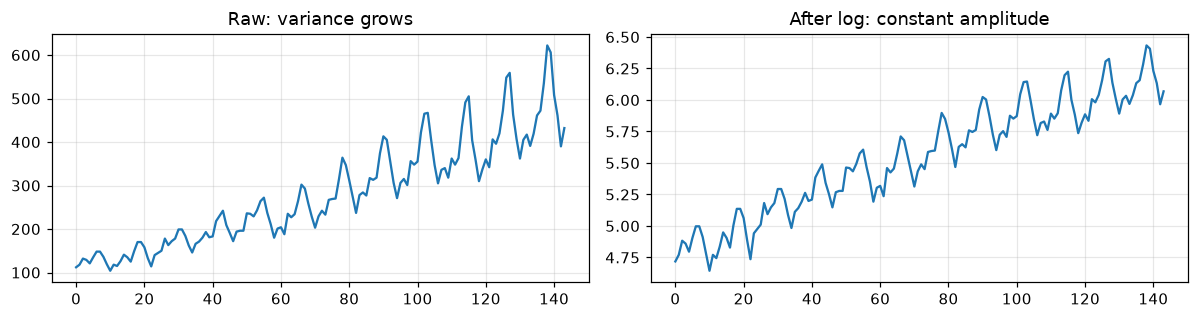

  That is what a log transform is FOR in forecasting - it turns multiplicative
  seasonality into additive seasonality, which every method handles better.
  With 144 points, this is also firmly classical-methods territory (Q10).


In [22]:
print("Bike sharing is cached from Part 1. Airline passengers ships with statsmodels:\n")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import statsmodels.api as sm
    air = sm.datasets.get_rdataset("AirPassengers").data

air.columns = ["time", "passengers"]
print(f"  airline passengers: {len(air)} monthly observations, "
      f"{air['passengers'].min()}-{air['passengers'].max()}")

print("\n  Why it is the classic teaching series: the seasonal amplitude GROWS with the level.")
first_half = air["passengers"].iloc[:72]
second_half = air["passengers"].iloc[72:]
print(f"    first 6 years : mean {first_half.mean():.0f}, std {first_half.std():.0f}, "
      f"std/mean {first_half.std()/first_half.mean():.3f}")
print(f"    last 6 years  : mean {second_half.mean():.0f}, std {second_half.std():.0f}, "
      f"std/mean {second_half.std()/second_half.mean():.3f}")
logged = np.log(air["passengers"])
print(f"    after a LOG transform, std/mean: "
      f"{logged.iloc[:72].std()/logged.iloc[:72].mean():.3f} then "
      f"{logged.iloc[72:].std()/logged.iloc[72:].mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(air["passengers"].to_numpy()); axes[0].set(title="Raw: variance grows")
axes[1].plot(np.log(air["passengers"]).to_numpy())
axes[1].set(title="After log: constant amplitude")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print("  That is what a log transform is FOR in forecasting - it turns multiplicative")
print("  seasonality into additive seasonality, which every method handles better.")
print("  With 144 points, this is also firmly classical-methods territory (Q10).")

### 1. Airline passengers — trend, seasonality, and only 144 points

```python
import statsmodels.api as sm
air = sm.datasets.get_rdataset("AirPassengers").data
```

The canonical teaching series: monthly totals 1949–1960, with a clear trend and a seasonal
amplitude that grows with the level.

1. Fit ETS and SARIMA. With 144 points this is Q10's "classical wins" case — confirm it by also
   fitting a gradient-boosted model on lag features and watching it struggle.
2. Apply a log transform first. Does it help both families equally?
3. Reproduce §1.6 here: does a tree on the raw series get stuck below the trend?
4. Decompose into trend / seasonal / residual with `seasonal_decompose` and `STL`. Which handles
   the growing amplitude better, and why?
5. Hold out the last 24 months and forecast. Plot prediction intervals (Q11) and check coverage.

***

### 2. Bike sharing — go further than Part 2

Used throughout Parts 2 and 3.

1. Build the **direct multi-horizon** models from Challenge 1 and plot MAE against horizon.
2. Reproduce §1.6's trend problem on the real data: train only on year 1, test on year 2, and
   compare a tree against a tree on the *differenced* series.
3. Add interaction features — `hour × workingday` explicitly — and see whether the gradient
   boosting already captured them.
4. Split the target into `casual` and `registered` riders if you fetch the original UCI version.
   They have very different daily profiles; does forecasting them separately and summing beat
   forecasting the total?
5. Run the §3.3 weather-degradation experiment properly: get real forecast-error magnitudes for
   24-hour temperature forecasts and use those.

***

### 3. Electricity load — multiple seasonalities at once

```python
from sklearn.datasets import fetch_openml
# e.g. "electricity-normalized" on OpenML, or the UCI household power consumption dataset
```

Load data has a daily cycle, a weekly cycle *and* a yearly cycle, plus holiday effects — the
regime where a single seasonal period is not enough.

1. Build lag features at 24, 168 and 8766 hours. Which matter most?
2. Fourier terms are the standard way to handle several seasonalities in one linear model: build
   sin/cos pairs at multiple frequencies (Q5 explains why one pair is not enough) and fit a
   linear model. Compare against the tree.
3. Public holidays break the weekly pattern. Add a holiday flag and measure the improvement
   specifically on holidays rather than on average.
4. Temperature has a **non-linear, U-shaped** effect on load — heating below, cooling above.
   Confirm with a partial dependence plot (NB-12 §1.5), and check whether a linear model can
   represent it.

***

### 4. M5 / retail sales — the real problem shape

```
# Kaggle: M5 Forecasting - Accuracy (30,490 series, daily, hierarchical)
```

Thousands of series at once, mostly intermittent (many zeros), organised in a hierarchy
(item → department → store → state).

1. Start with **ten** series, not 30,000. Fit seasonal naive and a global gradient-boosted model
   trained across all ten. Does the shared model beat per-series models?
2. **Intermittent demand** breaks most metrics: MAPE divides by zero, and MAE is minimised by
   predicting zero. Use MASE (§1.5), and read about Croston's method.
3. **Hierarchical coherence**: do your store-level forecasts sum to your state-level forecast?
   They will not. Read about reconciliation (MinT).
4. This is what the M5 competition scored with the weighted pinball loss (Q11). Implement it.
5. Read the M5 winners' write-ups. Note how much of the work is feature engineering and
   validation design rather than modelling.

***

### 5. Your own metric — the one that matters

Take something you actually care about: website traffic, personal spending, gym attendance,
server load, hours slept.

1. Collect at least two full seasonal cycles. If it is weekly-seasonal, that is a fortnight
   minimum; realistically you want months.
2. Run the full Part 2 workflow: baselines first, chronological split, MASE.
3. **Write down what a good forecast is worth** before you model. If a 20% error costs nothing,
   stop early. This is the step every tutorial skips and every real project needs.
4. Deploy it: forecast next week, write the number down, and check it. This is the only exercise
   in the series that gives you a genuine out-of-sample test, and it is humbling.

***
# Part 6 - Reading the literature

Forecasting has the best free textbook in machine learning and an unusually strong tradition of
open empirical competition, so the evidence here is better than in most of the field.

## Start here

**1. [Forecasting: Principles and Practice, 3rd edition](https://otexts.com/fpp3/)** —
Rob Hyndman & George Athanasopoulos. **Free online, complete.**
> **The book to read.** Comprehensive, practical, and free, from the person who invented MASE
> and wrote most of the standard tooling. Chapters 2–3 (features and decomposition), 5
> (baselines and evaluation) and 7–9 (ETS and ARIMA) cover everything in this notebook more
> thoroughly. The R examples translate readily.

**2. [On the use of cross-validation for time series predictor evaluation](https://www.sciencedirect.com/science/article/abs/pii/S0020025511006773)** —
Christoph Bergmeir & José Benítez, *Information Sciences* 191:192–213, 2012.
> **The paper behind §1.3 and §1.4.** It works through why standard cross-validation fails on
> dependent data and what to use instead. Read it with Bergmeir, Hyndman & Koo (2018), "A note
> on the validity of cross-validation for evaluating autoregressive time series prediction",
> which shows the more nuanced result: for purely autoregressive models with uncorrelated
> errors, k-fold CV can actually be valid. Knowing *when* the rule relaxes is worth more than
> the rule.

**3. [The M4 Competition: 100,000 time series and 61 forecasting methods](https://www.sciencedirect.com/science/article/pii/S0169207019301128)** —
Spyros Makridakis, Evangelos Spiliotis & Vassilios Assimakopoulos, *IJF* 36(1), 2020. **Free.**
> **The honest empirical record.** For decades the M-competitions found simple statistical
> methods beating sophisticated ones. M4 was the first where an ML method won — and the winner
> was a **hybrid** of exponential smoothing and a neural network, with the second place an
> ensemble. Read it before assuming gradient boosting is obviously the answer (Q10).

## The paper behind each section

| Section | Source | Free? |
|---|---|---|
| 1.2 — the supervised framing | **Hyndman & Athanasopoulos**, *FPP3* ch. 7 & 12 — [free](https://otexts.com/fpp3/) | ✅ |
| 1.3, 1.4 — **CV on dependent data** | **Bergmeir & Benítez**, Information Sciences **2012**; **Bergmeir, Hyndman & Koo**, CSDA 120, **2018** — [pdf](https://robjhyndman.com/papers/cv-wp.pdf) | ✅ |
| 1.5 — **MASE** | **Hyndman & Koehler**, *Another look at measures of forecast accuracy*, IJF 22(4), **2006** — [pdf](https://robjhyndman.com/papers/mase.pdf) | ✅ |
| 1.5 — why MAPE misleads | **Hyndman**, *Errors on percentage errors*, **2014** — [blog](https://robjhyndman.com/hyndsight/smape/) | ✅ |
| 1.6 — trees cannot extrapolate | Same argument as NB-03 and NB-07 §1.7; see also **Makridakis, Spiliotis & Assimakopoulos**, *Statistical and ML forecasting methods: concerns and ways forward*, PLOS ONE **2018** | ✅ |
| 1.7 — Fourier terms for seasonality | **Hyndman & Athanasopoulos**, *FPP3* §7.4 and §12.1 | ✅ |
| 1.8 — direct vs recursive multi-step | **Ben Taieb et al.**, *A review and comparison of strategies for multi-step ahead time series forecasting*, Expert Systems with Applications 39(8), **2012** | 🔍 |
| 3.1 — leakage in feature construction | NB-00 §2; and **Kaufman, Rosset & Perlich**, *Leakage in Data Mining*, KDD **2011** | 🔍 |
| 3.2 — ARIMA and state-space models | **Hyndman & Athanasopoulos**, *FPP3* ch. 8–9 | ✅ |
| Q10 — **the empirical record** | **Makridakis, Spiliotis & Assimakopoulos**, *The M4 Competition*, IJF **2020**; and *The M5 Accuracy competition*, IJF 38(4), **2022** | ✅ |
| Q11 — prediction intervals and pinball loss | *FPP3* ch. 5.5; and **Gneiting & Raftery**, *Strictly Proper Scoring Rules*, JASA 102, **2007** | ✅ |
| Q11 — conformal prediction for time series | **Stankeviciute, Alaa & van der Schaar**, *Conformal Time-Series Forecasting*, NeurIPS **2021** | ✅ |
| Part 5 — hierarchical reconciliation | **Wickramasuriya, Athanasopoulos & Hyndman**, *Optimal forecast reconciliation (MinT)*, JASA 114, **2019** | 🔍 |

**Legend:** ✅ free at the link · 🔍 search the exact title on
[Google Scholar](https://scholar.google.com)

### If you read only one

**Hyndman & Athanasopoulos, *FPP3*.** It is free, complete, actively maintained, and better than
anything you would pay for. Read chapter 5 tonight — it is the baselines and evaluation material
from §1.5, done properly — and keep the rest as a reference.

Then **the M4 paper** for the empirical humility, and **Bergmeir & Benítez** for the validation
argument this notebook is built around.

***
# Appendix

| Symptom | Cause | Fix |
|---|---|---|
| Great validation, poor production | **Random split** (§1.3) | Chronological split; `TimeSeriesSplit` |
| CV folds agree suspiciously closely | Every fold leaks identically (§1.4) | Use `TimeSeriesSplit`; expect a larger spread |
| A rolling feature helps a lot | Window includes the current row or the future (§3.1) | `.shift(h).rolling(w)` — shift **first** |
| Forecast is flat, or capped below the trend | Trees cannot extrapolate (§1.6) | Difference, detrend, or use a linear/ARIMA component |
| Residual bias grows over the test period | The same trend problem, in production form (§2.4) | Difference or detrend; retrain more often |
| Model barely beats seasonal naive | Normal, and worth knowing (§1.5) | Report MASE; if ≥ 1, the model adds nothing |
| Error does not grow with horizon as expected | Lag alignment with the season matters more (§1.8) | Use lags that are multiples of the seasonal period |
| `lag_24` is not 24 hours | Missing rows — `shift` counts **rows**, not time | Reindex to a complete time grid first |
| MAPE is infinite or enormous | Actuals near zero | Use MASE (§1.5) |
| sin/cos made the tree worse | Trees do not need cyclical encoding (§1.7) | Pass the raw integer to trees; encode for linear models |
| Intervals are the same width at every horizon | Validated at one horizon, deployed at another (Q11) | Produce and check intervals per horizon |
| Weather features work in backtest, not live | You trained on observed weather, deployed against forecasts (§3.3) | Validate with forecast-quality covariates |

## Checklist for shipping a forecast

- [ ] Is the split **chronological**, and is validation `TimeSeriesSplit` or walk-forward (§1.3, §1.4)?
- [ ] Is the **horizon** decided, and is every lag at least that old (§1.8)?
- [ ] Are lags **aligned to the seasonal period** where possible (§1.8)?
- [ ] Does every window feature `.shift()` **before** it rolls (§3.1)?
- [ ] Are **naive and seasonal-naive baselines** in the results table, with MASE (§1.5)?
- [ ] If the series **trends** and the model is tree-based: have I differenced or detrended (§1.6)?
- [ ] Have I checked the **residual bias over time**, not just the average error (§2.4)?
- [ ] Is the time grid **complete** — no missing hours silently shortening my lags?
- [ ] Will every feature be **available at forecast time**, at forecast quality (§3.3)?
- [ ] Do I know how fast the model **ages**, and is the retraining schedule set from that (§3.3)?
- [ ] Are there **prediction intervals**, and has their coverage been measured (Q11)?
- [ ] Do I know what a good forecast is **worth**?

## Where to go next

| Notebook | Why it follows |
|---|---|
| [`gradient_boosting_zero_to_hero.ipynb`](gradient_boosting_zero_to_hero.ipynb) | The model doing most of the work here, and the place its limitations are set out. |
| [`knn_zero_to_hero.ipynb`](knn_zero_to_hero.ipynb) | §1.7 there is the extrapolation argument behind §1.6, in its simplest form. |
| [`explainable_ai_zero_to_hero.ipynb`](explainable_ai_zero_to_hero.ipynb) | Partial dependence on `hour` is how you check the model learned the daily profile you expect. |
| `anomaly_detection_zero_to_hero.ipynb` | The other time-ordered problem: not "what comes next?" but "was that normal?" |

See [`README.md`](README.md) for the full roster, the reading order and the suggested paths.